# **ORGANIZATION & NOTEBOOK INITIALIZATION (RUN EVERYTIME)**

In [1]:
######################################################################
### IMPORT PACKAGES & SETUP NOTEBOOK (RUN AT BEGINNING EVERY TIME) ###
######################################################################

project_name = 'Phosphotriesterase_Wetlab_Data_Analysis'

### REPOSITORY ROOT (auto-detected -- nothing here needs editing) ###
# Walks up from the current directory looking for the repository markers, so
# this notebook works from a fresh clone anywhere on disk. Override by setting
# the ZINC_HYDRO_REPO environment variable if you have an unusual layout.
def _find_repo_root():
    import os as _os
    from pathlib import Path as _Path
    _markers = ('Scripts', 'Software', 'Environment', 'LICENSE')
    _start = _Path(_os.environ.get('ZINC_HYDRO_REPO') or _Path.cwd()).resolve()
    for _cand in (_start, *_start.parents):
        if all((_cand / _m).exists() for _m in _markers):
            return str(_cand)
    raise RuntimeError(
        f"Could not find the repository root above {_start}. "
        f"Start Jupyter from inside the cloned repository, or set ZINC_HYDRO_REPO."
    )

github_repo_dir = _find_repo_root()
# NOTE: this notebook needs no external tools -- only numpy/pandas/scipy/
#       matplotlib/openpyxl. Open Babel belongs to the DESIGN pipelines.

### STANDARD LIBRARY & THIRD-PARTY IMPORTS ###
import glob, json, math, os, re, sys, warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import AutoMinorLocator
from IPython.display import display

### PLATE-READER PARSING & FITTING ###
# Vendored under Scripts/wetlab_platereader/ so this notebook is self-contained.
_platereader = os.path.join(github_repo_dir, 'Scripts', 'wetlab_platereader')
if _platereader not in sys.path:
    sys.path.insert(0, _platereader)
from kinetics import parse_standard_curve, parse_kinetics, plot_kinetics, export_plot
from neo2_util import parse_neo2_kinetics

### DIRECTORIES ###
notebook_dir        = os.path.join(github_repo_dir, 'Manuscript_Data',
                                   'Phosphotriesterase_RFdiffusion3_Science_2026')
raw_wetlab_data_dir = os.path.join(notebook_dir, 'raw_wetlab_data')
wetlab_data_plots_dir = os.path.join(notebook_dir, 'wetlab_data_plots')
os.makedirs(wetlab_data_plots_dir, exist_ok=True)

def raw(prefix):
    """Absolute path to the one raw data file whose name starts with `prefix`.

    The instrument writes long descriptive filenames; matching on a short
    distinctive prefix keeps the cells below readable and fails loudly rather
    than silently picking the wrong plate.
    """
    hits = sorted(glob.glob(os.path.join(raw_wetlab_data_dir, prefix + '*')))
    if len(hits) != 1:
        raise FileNotFoundError(
            f"expected exactly one raw file starting with {prefix!r}, found {len(hits)}"
            + (":\n  " + "\n  ".join(os.path.basename(h) for h in hits) if hits else ""))
    return os.path.relpath(hits[0])

### FIGURE OUTPUT (applies to every figure this notebook writes) ###
# All figures are written to wetlab_data_plots/ as PNG. PNG at a modest DPI
# keeps the repository small -- these are the files committed to GitHub.
# EPS is vector and much larger, so it is off by default; flip SAVE_EPS to True
# (or pass save_eps=True at a single call site) when you need one for a figure.
FIGURE_DPI = 150     # raster resolution for the PNGs
SAVE_EPS   = False   # also write <name>.eps alongside <name>.png

def save_figure(name, fig=None, dpi=None, save_eps=None):
    """Write a figure to wetlab_data_plots/ as PNG (and optionally EPS).

    Pass `fig` explicitly wherever you can. The plotting helpers call plt.show()
    before returning, and under Jupyter's inline backend that closes the figure,
    so a later plt.gcf() would hand back a fresh empty one and save a blank PNG.
    """
    stem = os.path.relpath(os.path.join(wetlab_data_plots_dir, name))
    export_plot(f'{stem}.png', fig=fig, dpi=FIGURE_DPI if dpi is None else dpi, transparent=False)
    if SAVE_EPS if save_eps is None else save_eps:
        export_plot(f'{stem}.eps', fig=fig, transparent=False)
    return f'{stem}.png'

### CALIBRATION CONSTANTS (derived in section I.I; hard-coded here so every ###
### kinetics cell below can be run on its own without re-running section I) ###
SPU_NOBIC = 0.00633035   # signal per uM 4-nitrophenol, legacy buffer, no NaHCO3
SPU_BIC   = 0.00667808   # signal per uM 4-nitrophenol, legacy buffer + 25 mM NaHCO3

### FITTED KINETICS ARE COLLECTED HERE AND SUMMARIZED IN SECTION III ###
FITS = {}

### OPTIONALS ###
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
warnings.filterwarnings('ignore', category=RuntimeWarning)

### PRINTS ###
print(f"### PROJECT {project_name} NOTEBOOK SUCCESSFULLY INITIALIZED ON {datetime.now():%Y-%m-%d %H:%M} ###\n")
print("Repository located.")
print(f"raw data        : {os.path.relpath(raw_wetlab_data_dir)}  ({len(os.listdir(raw_wetlab_data_dir))} files)")
print(f"figures         : {os.path.relpath(wetlab_data_plots_dir)}  (PNG @ {FIGURE_DPI} dpi, EPS {'on' if SAVE_EPS else 'off'})")

### PROJECT Phosphotriesterase_Wetlab_Data_Analysis NOTEBOOK SUCCESSFULLY INITIALIZED ON 2026-09-29 22:14 ###

Repository located.
raw data        : raw_wetlab_data  (16 files)
figures         : wetlab_data_plots  (PNG @ 150 dpi, EPS off)


# **I. CALIBRATION & BACKGROUND REACTION RATE**

## I.I. 4-Nitrophenol Standard Curves

Paraoxon hydrolysis is followed at 405 nm, where the product 4-nitrophenol
absorbs. Converting absorbance to product concentration needs a calibration
slope measured in the same buffer as the reaction, because 4-nitrophenol's
extinction coefficient depends on pH and the phenolate/phenol ratio shifts
with buffer composition.

One plate covers four conditions in triplicate: two buffers ("legacy" and
"modern") each with and without 25 mM NaHCO<sub>3</sub>, over an eight-point
serial dilution from 200 µM. The kinetics below were all run in legacy buffer,
so they use the first two slopes.

In [2]:
######################################################
### 4-NITROPHENOL STANDARD CURVES (FOUR CONDITIONS) ##
######################################################

### INPUT ###
standard_curve_file = raw('260225_StdCurve_200uMserials_vert__80uL')
CONC_STD = [200, 100, 50, 25, 12.5, 6.25, 3.175, 1.5875]   # uM, serial dilution down the rows

### CONDITIONS (three replicate columns each) ###
STD_CONDITIONS = [
    ("legacy buffer, no NaHCO3",        [1, 2, 3]),
    ("legacy buffer + 25 mM NaHCO3",    [4, 5, 6]),
    ("modern buffer, no NaHCO3",        [7, 8, 9]),
    ("modern buffer + 25 mM NaHCO3",    [10, 11, 12]),
]

### EXECUTION ###
print(f"{'condition':32} {'columns':14} slope (signal per uM)")
print("-" * 70)
standard_curve_slopes = {}
for name, cols in STD_CONDITIONS:
    slope, _ = parse_standard_curve(
        data_path=standard_curve_file,
        blocks=[dict(rows=list("ABCDEFGH"), concentrations_uM=CONC_STD, replicate_cols=cols)],
        force_zero_intercept=False, plot=False)
    standard_curve_slopes[name] = slope
    print(f"{name:32} {str(cols):14} {slope:.8f}")

print(f"\nThe two legacy-buffer slopes are the ones used below:")
print(f"  SPU_NOBIC = {SPU_NOBIC:.8f}   SPU_BIC = {SPU_BIC:.8f}")

condition                        columns        slope (signal per uM)
----------------------------------------------------------------------
Parsing [raw_wetlab_data/260225_StdCurve_200uMserials_vert__80uL__legacyX3__legacyW25mMbicarbX3__modernX3__modernW25mMbicarbX3_1prctMeOH.xlsx] Measured at [2026-02-25 22:33:55]...

Standard curve fit:
  slope     = 0.00633035  (signal per uM)
  intercept = 0.0884093
  R^2       = 0.9999
  blank     = 0  (subtracted before fit)

Copy into kinetics cell:  signal_per_uM = 0.00633035

legacy buffer, no NaHCO3         [1, 2, 3]      0.00633035
Parsing [raw_wetlab_data/260225_StdCurve_200uMserials_vert__80uL__legacyX3__legacyW25mMbicarbX3__modernX3__modernW25mMbicarbX3_1prctMeOH.xlsx] Measured at [2026-02-25 22:33:55]...

Standard curve fit:
  slope     = 0.00667808  (signal per uM)
  intercept = 0.103496
  R^2       = 1.0000
  blank     = 0  (subtracted before fit)

Copy into kinetics cell:  signal_per_uM = 0.00667808

legacy buffer + 25 mM NaHCO3     

## I.II. Uncatalyzed Rate for Paraoxon Hydrolysis (*k*<sub>uncat</sub>)

Enzyme-free paraoxon hydrolysis, 0.3–9.6 mM, followed for 4.5 h, with and
without 25 mM NaHCO<sub>3</sub>.

*k*<sub>uncat</sub> is the slope of v<sub>0</sub> against [S] fitted with a
**free intercept**, which absorbs substrate-independent baseline drift.
Subtracting that intercept from every v<sub>0</sub> and refitting through the
origin returns the same slope, so the free-intercept fit is used directly.

Rather than choosing one fit window by hand, every admissible window is scanned
(at least 45 min long, R<sup>2</sup> ≥ 0.90, on a 5-min grid) and the reported
value is the median across them. The uncertainty combines the 16th–84th
percentile spread across windows with the median within-window regression
error, so it reflects both the choice of window and the fit itself.

In [3]:
##########################################################
### UNCATALYZED PARAOXON HYDROLYSIS (k_uncat), +/- HCO3 ##
##########################################################

### INPUT ###
kuncat_file = raw('260807_kuncat_legacy_buffer')
ROWS_K = list("ABCDEF")                                   # one row per [paraoxon]
CONC_K = np.array([9600, 4800, 2400, 1200, 600, 300], float)   # uM
KCFG = {"no NaHCO3":     dict(cols=[1, 2, 3], spu=SPU_NOBIC),
        "+25 mM NaHCO3": dict(cols=[4, 5, 6], spu=SPU_BIC)}

### LOAD AND RESHAPE THE TIME COURSE ###
_raw_kuncat = parse_neo2_kinetics(kuncat_file)
_d = _raw_kuncat.groupby(["Well", "time"], as_index=False).agg(signal=("value", "mean"))
_d["time"] = _d["time"].astype(float) - _d.groupby("Well")["time"].transform("min")
KPIV = _d.pivot(index="time", columns="Well", values="signal").sort_index()
KT = KPIV.index.to_numpy(float)

### FITTING ###
def kuncat_block(condition, lo, hi):
    """Mean v0 per [S] over one fit window, plus the free-intercept fit."""
    cfg = KCFG[condition]
    m = (KT >= lo) & (KT <= hi)
    tt = KT[m]
    reps = [np.polyfit(tt, np.column_stack([KPIV[f"{r}{c}"].to_numpy(float)[m]
            for c in cfg["cols"]]), 1)[0] / cfg["spu"] for r in ROWS_K]
    V = np.array([x.mean() for x in reps])
    E = np.array([x.std(ddof=1) / np.sqrt(len(x)) for x in reps])
    k, c = np.polyfit(CONC_K, V, 1)
    pred = k * CONC_K + c
    ss = np.sum((V - V.mean()) ** 2)
    return k, c, (1 - np.sum((V - pred) ** 2) / ss if ss > 0 else np.nan), V, E

def kuncat_report(condition, grid=300., min_duration=2700., min_start=900.):
    """Median k_uncat over every admissible fit window, with combined error."""
    accepted = []
    for lo in np.arange(min_start, KT.max() - min_duration + 1, grid):
        for hi in np.arange(lo + min_duration, KT.max() + 1, grid):
            k, c, r2, V, E = kuncat_block(condition, lo, hi)
            if r2 >= 0.90:
                # leave-one-out spread across the six substrate concentrations
                jk = np.array([np.polyfit(np.delete(CONC_K, i), np.delete(V, i), 1)[0]
                               for i in range(len(CONC_K))])
                accepted.append((lo, hi, k, np.sqrt(5/6 * np.sum((jk - jk.mean()) ** 2))))
    A = np.array(accepted)
    k = A[:, 2]
    median = np.median(k)
    p16, p84 = np.percentile(k, [16, 84])
    stat = np.median(A[:, 3])
    err = max(np.hypot(median - p16, stat), np.hypot(p84 - median, stat))
    best = A[np.argmin(np.abs(k - median))]        # the window closest to the median
    return dict(k=median, err=err, n=len(A), lo=best[0], hi=best[1])

### EXECUTION ###
KUNCAT = {c: kuncat_report(c) for c in KCFG}
for condition, r in KUNCAT.items():
    half_life_lo = np.log(2) / (r["k"] + r["err"]) / 86400
    half_life_hi = np.log(2) / (r["k"] - r["err"]) / 86400
    print(f"{condition:16} k_uncat = ({r['k']*1e8:.1f} +/- {r['err']*1e8:.1f}) x 1e-8 s^-1"
          f"   t_1/2 = {half_life_lo:.0f}-{half_life_hi:.0f} d   ({r['n']} windows)")

no NaHCO3        k_uncat = (5.4 +/- 0.3) x 1e-8 s^-1   t_1/2 = 141-157 d   (903 windows)
+25 mM NaHCO3    k_uncat = (5.0 +/- 1.3) x 1e-8 s^-1   t_1/2 = 127-219 d   (838 windows)


# **II. MICHAELIS-MENTEN KINETICS**

## II.I. Shared Fitting Routine

Every design below was measured the same way, so they all go through one
routine. A plate holds three enzyme replicate columns and one background column
per design, with paraoxon serially diluted down rows A–F (9.6 mM to 0.3 mM).

For each design the routine fits an initial rate to every enzyme replicate and
every background replicate independently, subtracts the per-row mean background
slope from each enzyme replicate, converts signal to product with the
condition-matched calibration slope, and fits Michaelis–Menten to the mean
rates. Fits are collected in `FITS` and summarized in section III.

`time_range_seconds` is the window over which initial rates are taken. It is
shorter for the plates where product accumulates fastest.
The RFdiffusion3 helper preserves the paper's purple concentration palette, scaffold colors, full progress curves and annotations. The underlying rate/MM fitter is unchanged. Published H89A and H170A panels report a first-order slope because separate kcat and KM are not resolved.


In [4]:
##################################################
### RFdiffusion3-SPECIFIC FITTING AND PAPER STYLE ###
##################################################
from kinetics_pte_rfd3 import run_kinetics_PTE_RFd3 as _run_kinetics_PTE_RFd3
from kinetics_pte_rfd3 import validate_reference, reproduce_paper_figures, result_row

def run_kinetics_PTE_RFd3(name, *, file_prefix, enzyme_uM, enzyme_cols, bg_cols,
                         condition="+25 mM NaHCO3", time_range_seconds=(300, 20000),
                         plot_name=None, scaffold=None, plate_id=None, show=True):
    mm = _run_kinetics_PTE_RFd3(
        name, data_path=raw(file_prefix), enzyme_uM=enzyme_uM,
        enzyme_cols=enzyme_cols, bg_cols=bg_cols, condition=condition,
        time_range_seconds=time_range_seconds, show=show, save_eps=SAVE_EPS,
        plot_path=os.path.join(wetlab_data_plots_dir, plot_name + '.png') if plot_name else None)
    FITS[name] = dict(mm=mm, condition=condition, enzyme_uM=enzyme_uM,
                      scaffold=scaffold, plate_id=plate_id)
    return mm


## II.II. Round 1 Designs (PET_i1 Scaffold)

The four designs carried forward from the first design round, all on the same
scaffold. ZAPP-1 was additionally measured without bicarbonate as a control on
the buffer condition; that run uses the no-bicarbonate calibration slope.

### II.II.A. ZAPP-1 (p1D1)

[E]<sub>0</sub> = 24.0 µM, paraoxon 0.3–9.6 mM, 25 mM NaHCO₃, 1 % MeOH, 405 nm.

Parsing [raw_wetlab_data/260804_ZAPP1strp_24uM__p1D9_44pt6uM__p1H4_39pt1uM__80uL_1prctMeOH_trip_blank__leg_buff__9pt6mMpxn_serialDIL_30m_25finalbica.xlsx] Measured at [2026-08-05 17:07:23]...
Parsing [raw_wetlab_data/260804_ZAPP1strp_24uM__p1D9_44pt6uM__p1H4_39pt1uM__80uL_1prctMeOH_trip_blank__leg_buff__9pt6mMpxn_serialDIL_30m_25finalbica.xlsx] Measured at [2026-08-05 17:07:23]...


findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.


findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


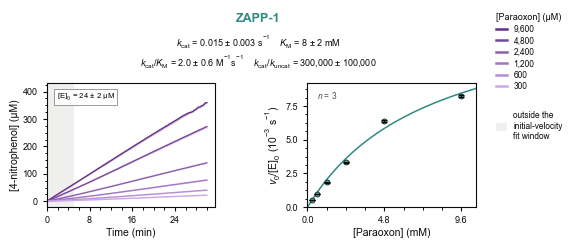

{'Vmax_uM_per_s': 0.3675071824566877,
 'Vmax_err_uM_per_s': 0.04857764631856642,
 'Km_uM': 7778.227140228582,
 'Km_err_uM': 1825.282347541013,
 'kcat_per_s': 0.015312799269028654,
 'kcat_err_per_s': 0.002024068596606934,
 'kcat_over_Km_per_uM_per_s': 1.9686747369245184e-06,
 'kcat_over_Km_err_per_uM_per_s': np.float64(5.302277034831439e-07),
 'kuncat_per_s': 1.488004590602719e-07,
 'kcat_over_kuncat': 102908.27975756564,
 'MM_R2': 0.9902805631900278,
 'kuncat_R2': 0.941127163319991,
 'enzyme_uM': 24.0,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 20000),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.013150        0.000823  3
 1             600.0         0.023522        0.001194  3
 2            1200.0         0.044496        0.001712  3
 3            2400.0         0.079952        0.001722  3
 4            4800.0         0.153511        0.003481  3
 5            9600.0         0.198229        0.003396  3,
 '_bg_by_row':   

In [5]:
run_kinetics_PTE_RFd3(
    'ZAPP-1',
    file_prefix = '260804_ZAPP1strp_24uM',
    enzyme_uM   = 24.0,
    enzyme_cols = [1, 2, 3], bg_cols = [4],
    scaffold    = 'PET_i1',
    plate_id    = 'p1D1',
    plot_name   = 'kinetics_ZAPP1_p1D1',
)

### II.II.B. ZAPP-1 (p1D1), without bicarbonate

[E]<sub>0</sub> = 37.3 µM, paraoxon 0.3–9.6 mM, no NaHCO₃, 1 % MeOH, 405 nm.

Buffer control. Fitted with `SPU_NOBIC`, the calibration slope measured in the same buffer, so it is directly comparable to the run above.

Parsing [raw_wetlab_data/260225_p1D1_30pt9uM__p1D8_39pt8uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_20m__NObicarb_added.xlsx] Measured at [2026-02-26 01:40:30]...
Parsing [raw_wetlab_data/260225_p1D1_30pt9uM__p1D8_39pt8uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_20m__NObicarb_added.xlsx] Measured at [2026-02-26 01:40:30]...


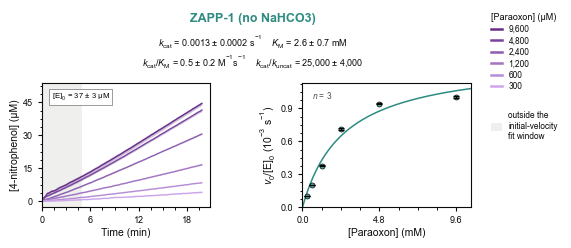

{'Vmax_uM_per_s': 0.05015639841499101,
 'Vmax_err_uM_per_s': 0.004998091786951459,
 'Km_uM': 2577.973063385286,
 'Km_err_uM': 652.1993137124432,
 'kcat_per_s': 0.0013446755607236197,
 'kcat_err_per_s': 0.00013399709884588364,
 'kcat_over_Km_per_uM_per_s': 5.216018661412421e-07,
 'kcat_over_Km_err_per_uM_per_s': np.float64(1.4182744991192796e-07),
 'kuncat_per_s': 6.155510396442651e-08,
 'kcat_over_kuncat': 21845.07009363066,
 'MM_R2': 0.9745829956797902,
 'kuncat_R2': 0.4766115340314089,
 'enzyme_uM': 37.3,
 'signal_per_uM': 0.00633035,
 'time_range_seconds': (300, 20000),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.003781        0.000236  3
 1             600.0         0.007579        0.000098  3
 2            1200.0         0.014150        0.000156  3
 3            2400.0         0.026551        0.000660  3
 4            4800.0         0.035206        0.000512  3
 5            9600.0         0.037326        0.000559  3,
 '_bg_by_row

In [6]:
run_kinetics_PTE_RFd3(
    'ZAPP-1 (no NaHCO3)',
    file_prefix = '260225_p1D1_30pt9uM',
    enzyme_uM   = 37.3,
    enzyme_cols = [1, 2, 3], bg_cols = [4],
    condition   = 'no NaHCO3',
    scaffold    = 'PET_i1',
    plate_id    = 'p1D1',
    plot_name   = 'kinetics_ZAPP1_p1D1_no_bicarbonate',
)

### II.II.C. R1 p1D7

[E]<sub>0</sub> = 21.3 µM, paraoxon 0.3–9.6 mM, 25 mM NaHCO₃, 1 % MeOH, 405 nm.

Parsing [raw_wetlab_data/260224_p1D7_21pt3uM__p1E10_15pt3uM__p3C11_27pt1uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_20m__25finalbicarb_after3hr.xlsx] Measured at [2026-02-24 18:44:55]...
Parsing [raw_wetlab_data/260224_p1D7_21pt3uM__p1E10_15pt3uM__p3C11_27pt1uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_20m__25finalbicarb_after3hr.xlsx] Measured at [2026-02-24 18:44:55]...


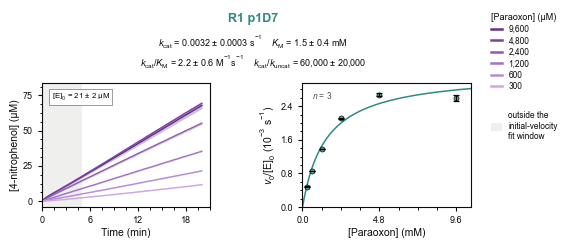

{'Vmax_uM_per_s': 0.06825826169572398,
 'Vmax_err_uM_per_s': 0.00474160079202327,
 'Km_uM': 1452.8361502126318,
 'Km_err_uM': 305.1803397237077,
 'kcat_per_s': 0.0032046132251513605,
 'kcat_err_per_s': 0.00022261036582268872,
 'kcat_over_Km_per_uM_per_s': 2.2057636882743765e-06,
 'kcat_over_Km_err_per_uM_per_s': np.float64(4.880172885732814e-07),
 'kuncat_per_s': 1.4227809803301643e-07,
 'kcat_over_kuncat': 22523.587744388544,
 'MM_R2': 0.9736981964449547,
 'kuncat_R2': 0.9121797547967521,
 'enzyme_uM': 21.3,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 20000),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.010366        0.000246  3
 1             600.0         0.018297        0.000305  3
 2            1200.0         0.029334        0.000137  3
 3            2400.0         0.044992        0.000501  3
 4            4800.0         0.056878        0.001309  3
 5            9600.0         0.055173        0.002923  3,
 '_bg_by_r

In [7]:
run_kinetics_PTE_RFd3(
    'R1 p1D7',
    file_prefix = '260224_p1D7_21pt3uM',
    enzyme_uM   = 21.3,
    enzyme_cols = [1, 2, 3], bg_cols = [4],
    scaffold    = 'PET_i1',
    plate_id    = 'p1D7',
    plot_name   = 'kinetics_R1_p1D7',
)

### II.II.D. R1 p1D8

[E]<sub>0</sub> = 26.1 µM, paraoxon 0.3–9.6 mM, 25 mM NaHCO₃, 1 % MeOH, 405 nm.

Parsing [raw_wetlab_data/260224_p1D1_26pt2uM__p1D8_26pt1uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_20m__25finalbicarb_after3hr.xlsx] Measured at [2026-02-24 16:55:59]...
Parsing [raw_wetlab_data/260224_p1D1_26pt2uM__p1D8_26pt1uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_20m__25finalbicarb_after3hr.xlsx] Measured at [2026-02-24 16:55:59]...


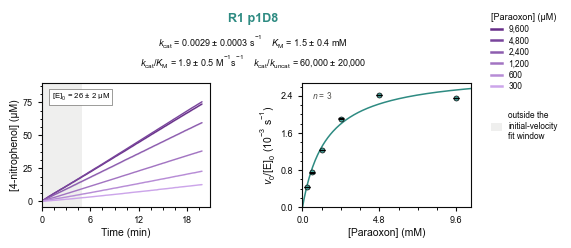

{'Vmax_uM_per_s': 0.07634133745629568,
 'Vmax_err_uM_per_s': 0.005433830155039658,
 'Km_uM': 1502.0335845541242,
 'Km_err_uM': 320.10485678612554,
 'kcat_per_s': 0.0029249554580956195,
 'kcat_err_per_s': 0.00020819272624673018,
 'kcat_over_Km_per_uM_per_s': 1.947330264898096e-06,
 'kcat_over_Km_err_per_uM_per_s': np.float64(4.375388526935611e-07),
 'kuncat_per_s': 9.743541826819347e-08,
 'kcat_over_kuncat': 30019.427330261005,
 'MM_R2': 0.9735419321262242,
 'kuncat_R2': 0.8717450010789712,
 'enzyme_uM': 26.1,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 20000),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.011335        0.000183  3
 1             600.0         0.019603        0.000140  3
 2            1200.0         0.032271        0.000222  3
 3            2400.0         0.049785        0.000383  3
 4            4800.0         0.063130        0.000123  3
 5            9600.0         0.061435        0.000397  3,
 '_bg_by_r

In [8]:
run_kinetics_PTE_RFd3(
    'R1 p1D8',
    file_prefix = '260224_p1D1_26pt2uM',
    enzyme_uM   = 26.1,
    enzyme_cols = [5, 6, 7], bg_cols = [8],
    scaffold    = 'PET_i1',
    plate_id    = 'p1D8',
    plot_name   = 'kinetics_R1_p1D8',
)

### II.II.E. R1 p1E10

[E]<sub>0</sub> = 15.3 µM, paraoxon 0.3–9.6 mM, 25 mM NaHCO₃, 1 % MeOH, 405 nm.

Parsing [raw_wetlab_data/260224_p1D7_21pt3uM__p1E10_15pt3uM__p3C11_27pt1uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_20m__25finalbicarb_after3hr.xlsx] Measured at [2026-02-24 18:44:55]...
Parsing [raw_wetlab_data/260224_p1D7_21pt3uM__p1E10_15pt3uM__p3C11_27pt1uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_20m__25finalbicarb_after3hr.xlsx] Measured at [2026-02-24 18:44:55]...


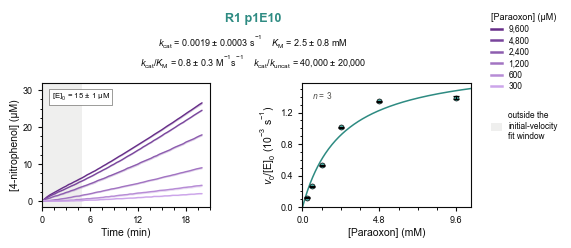

{'Vmax_uM_per_s': 0.028419710661145244,
 'Vmax_err_uM_per_s': 0.0033047228044106084,
 'Km_uM': 2467.0861586987126,
 'Km_err_uM': 738.4321448448377,
 'kcat_per_s': 0.0018574974288330223,
 'kcat_err_per_s': 0.00021599495453664106,
 'kcat_over_Km_per_uM_per_s': 7.529114547879335e-07,
 'kcat_over_Km_err_per_uM_per_s': np.float64(2.4176576899862466e-07),
 'kuncat_per_s': 1.485091074618523e-07,
 'kcat_over_kuncat': 12507.633104657638,
 'MM_R2': 0.9654940954400306,
 'kuncat_R2': 0.9004741343051671,
 'enzyme_uM': 15.3,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 20000),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.001833        0.000142  3
 1             600.0         0.004060        0.000232  3
 2            1200.0         0.008142        0.000177  3
 3            2400.0         0.015463        0.000076  3
 4            4800.0         0.020529        0.000053  3
 5            9600.0         0.021267        0.000453  3,
 '_bg_by

In [9]:
run_kinetics_PTE_RFd3(
    'R1 p1E10',
    file_prefix = '260224_p1D7_21pt3uM',
    enzyme_uM   = 15.3,
    enzyme_cols = [5, 6, 7], bg_cols = [8],
    scaffold    = 'PET_i1',
    plate_id    = 'p1E10',
    plot_name   = 'kinetics_R1_p1E10',
)

## II.III. Round 2 Designs (PTE_i2 Scaffolds)

Seven designs from the second round, spanning four scaffolds (s1, s3, s6, s7).
Where product accumulates fastest the initial-rate window is shortened to
300–660 s so the fit stays in the linear region of the progress curve.

### II.III.A. ZAPP-2 (p2C4), scaffold 3

[E]<sub>0</sub> = 26.6 µM, paraoxon 0.3–9.6 mM, 25 mM NaHCO₃, 1 % MeOH, 405 nm.

Parsing [raw_wetlab_data/260731_p1F6_34pt8uM__p2C4_26pt6uM__p2B12_10pt3uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_30m__25finalbicarb_after3hr.xlsx] Measured at [2026-07-31 20:48:22]...
Parsing [raw_wetlab_data/260731_p1F6_34pt8uM__p2C4_26pt6uM__p2B12_10pt3uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_30m__25finalbicarb_after3hr.xlsx] Measured at [2026-07-31 20:48:22]...


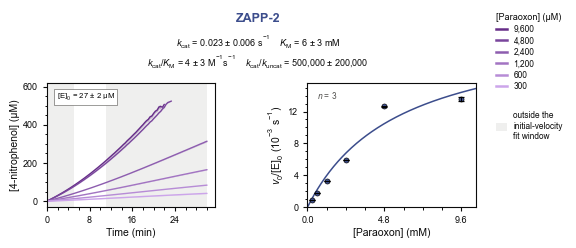

{'Vmax_uM_per_s': 0.6115120856728529,
 'Vmax_err_uM_per_s': 0.14309180449733586,
 'Km_uM': 5727.348210018763,
 'Km_err_uM': 2626.7541897779224,
 'kcat_per_s': 0.022989176153114767,
 'kcat_err_per_s': 0.005379391146516386,
 'kcat_over_Km_per_uM_per_s': 4.013930236143169e-06,
 'kcat_over_Km_err_per_uM_per_s': np.float64(2.0666838006131707e-06),
 'kuncat_per_s': 8.59013912876228e-08,
 'kcat_over_kuncat': 267622.86161513184,
 'MM_R2': 0.9547431724744592,
 'kuncat_R2': 0.4254129167959725,
 'enzyme_uM': 26.6,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 660),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.023311        0.001578  3
 1             600.0         0.046386        0.000698  3
 2            1200.0         0.087639        0.002355  3
 3            2400.0         0.157936        0.001551  3
 4            4800.0         0.335947        0.003079  3
 5            9600.0         0.359481        0.011589  3,
 '_bg_by_row':    

In [10]:
run_kinetics_PTE_RFd3(
    'ZAPP-2',
    file_prefix = '260731_p1F6_34pt8uM',
    enzyme_uM   = 26.6,
    enzyme_cols = [5, 6, 7], bg_cols = [8],
    time_range_seconds = (300, 660),
    scaffold    = 'PTE_i2_s3',
    plate_id    = 'p2C4',
    plot_name   = 'kinetics_ZAPP2_p2C4',
)

### II.III.B. R2 p2B12, scaffold 3

[E]<sub>0</sub> = 10.3 µM, paraoxon 0.3–9.6 mM, 25 mM NaHCO₃, 1 % MeOH, 405 nm.

Parsing [raw_wetlab_data/260731_p1F6_34pt8uM__p2C4_26pt6uM__p2B12_10pt3uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_30m__25finalbicarb_after3hr.xlsx] Measured at [2026-07-31 20:48:22]...
Parsing [raw_wetlab_data/260731_p1F6_34pt8uM__p2C4_26pt6uM__p2B12_10pt3uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_30m__25finalbicarb_after3hr.xlsx] Measured at [2026-07-31 20:48:22]...


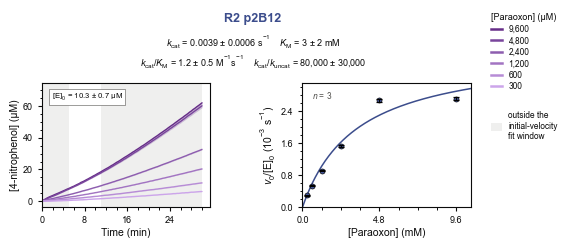

{'Vmax_uM_per_s': 0.04043983218710236,
 'Vmax_err_uM_per_s': 0.005642846347972561,
 'Km_uM': 3383.8369602946095,
 'Km_err_uM': 1099.1678619085008,
 'kcat_per_s': 0.003926197299718675,
 'kcat_err_per_s': 0.000547849159997336,
 'kcat_over_Km_per_uM_per_s': 1.1602796901233817e-06,
 'kcat_over_Km_err_per_uM_per_s': np.float64(4.101950721292778e-07),
 'kuncat_per_s': 1.3087291876530984e-07,
 'kcat_over_kuncat': 30000.074398580487,
 'MM_R2': 0.9639743330662549,
 'kuncat_R2': 0.8606580805413204,
 'enzyme_uM': 10.3,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 660),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.003043        0.000202  3
 1             600.0         0.005569        0.000182  3
 2            1200.0         0.009457        0.000151  3
 3            2400.0         0.015701        0.000485  3
 4            4800.0         0.027567        0.000762  3
 5            9600.0         0.027987        0.000587  3,
 '_bg_by_row'

In [11]:
run_kinetics_PTE_RFd3(
    'R2 p2B12',
    file_prefix = '260731_p1F6_34pt8uM',
    enzyme_uM   = 10.3,
    enzyme_cols = [9, 10, 11], bg_cols = [12],
    time_range_seconds = (300, 660),
    scaffold    = 'PTE_i2_s3',
    plate_id    = 'p2B12',
    plot_name   = 'kinetics_R2_p2B12',
)

### II.III.C. ZAPP-3 (p2G1), scaffold 7

[E]<sub>0</sub> = 27.5 µM, paraoxon 0.3–9.6 mM, 25 mM NaHCO₃, 1 % MeOH, 405 nm.

Parsing [raw_wetlab_data/260731_p2E3_28pt9uM__p2G1_27pt5uM__ZAPP1tagless_23pt4uM_80uL_1prctMeOH_trip_blak__legacy_buf_9pt6mMpxn_serialDIL_30m_25bic.xlsx] Measured at [2026-07-31 21:24:14]...
Parsing [raw_wetlab_data/260731_p2E3_28pt9uM__p2G1_27pt5uM__ZAPP1tagless_23pt4uM_80uL_1prctMeOH_trip_blak__legacy_buf_9pt6mMpxn_serialDIL_30m_25bic.xlsx] Measured at [2026-07-31 21:24:14]...


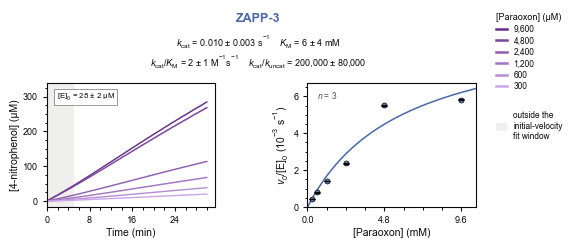

{'Vmax_uM_per_s': 0.2763954780876469,
 'Vmax_err_uM_per_s': 0.07323176409016707,
 'Km_uM': 5949.882471072059,
 'Km_err_uM': 3051.552714380252,
 'kcat_per_s': 0.010050744657732615,
 'kcat_err_per_s': 0.002662973239642439,
 'kcat_over_Km_per_uM_per_s': 1.6892341498506366e-06,
 'kcat_over_Km_err_per_uM_per_s': np.float64(9.75146066254151e-07),
 'kuncat_per_s': 1.5335226716499887e-07,
 'kcat_over_kuncat': 65540.24171627374,
 'MM_R2': 0.9449884312100136,
 'kuncat_R2': 0.8639449924752803,
 'enzyme_uM': 27.5,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 20000),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.011780        0.000282  3
 1             600.0         0.021903        0.000081  3
 2            1200.0         0.039030        0.000958  3
 3            2400.0         0.065060        0.000610  3
 4            4800.0         0.151259        0.001747  3
 5            9600.0         0.159819        0.000963  3,
 '_bg_by_row':   

In [12]:
run_kinetics_PTE_RFd3(
    'ZAPP-3',
    file_prefix = '260731_p2E3_28pt9uM',
    enzyme_uM   = 27.5,
    enzyme_cols = [5, 6, 7], bg_cols = [8],
    scaffold    = 'PTE_i2_s7',
    plate_id    = 'p2G1',
    plot_name   = 'kinetics_ZAPP3_p2G1',
)

### II.III.D. ZAPP-4 (p2E3), scaffold 6

[E]<sub>0</sub> = 28.9 µM, paraoxon 0.3–9.6 mM, 25 mM NaHCO₃, 1 % MeOH, 405 nm.

Parsing [raw_wetlab_data/260731_p2E3_28pt9uM__p2G1_27pt5uM__ZAPP1tagless_23pt4uM_80uL_1prctMeOH_trip_blak__legacy_buf_9pt6mMpxn_serialDIL_30m_25bic.xlsx] Measured at [2026-07-31 21:24:14]...
Parsing [raw_wetlab_data/260731_p2E3_28pt9uM__p2G1_27pt5uM__ZAPP1tagless_23pt4uM_80uL_1prctMeOH_trip_blak__legacy_buf_9pt6mMpxn_serialDIL_30m_25bic.xlsx] Measured at [2026-07-31 21:24:14]...


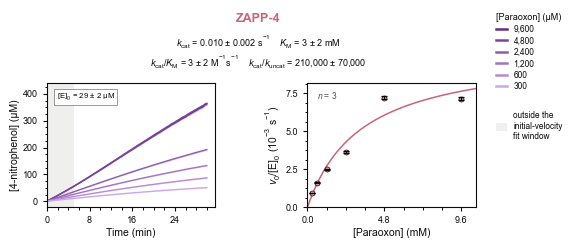

{'Vmax_uM_per_s': 0.2982300883570698,
 'Vmax_err_uM_per_s': 0.05071057532886963,
 'Km_uM': 3372.4938411269195,
 'Km_err_uM': 1336.3947277088348,
 'kcat_per_s': 0.010319380219967814,
 'kcat_err_per_s': 0.0017546911878501602,
 'kcat_over_Km_per_uM_per_s': 3.0598662906733705e-06,
 'kcat_over_Km_err_per_uM_per_s': np.float64(1.3194286760560576e-06),
 'kuncat_per_s': 1.1481799097491264e-07,
 'kcat_over_kuncat': 89875.98661452424,
 'MM_R2': 0.9449999915273382,
 'kuncat_R2': 0.9428498709312969,
 'enzyme_uM': 28.9,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 20000),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.026810        0.000316  3
 1             600.0         0.046621        0.001956  3
 2            1200.0         0.071955        0.001873  3
 3            2400.0         0.105545        0.002721  3
 4            4800.0         0.208685        0.006252  3
 5            9600.0         0.206103        0.004628  3,
 '_bg_by_row

In [13]:
run_kinetics_PTE_RFd3(
    'ZAPP-4',
    file_prefix = '260731_p2E3_28pt9uM',
    enzyme_uM   = 28.9,
    enzyme_cols = [1, 2, 3], bg_cols = [4],
    scaffold    = 'PTE_i2_s6',
    plate_id    = 'p2E3',
    plot_name   = 'kinetics_ZAPP4_p2E3',
)

### II.III.E. ZAPP-5 (p1F6), scaffold 1

[E]<sub>0</sub> = 34.8 µM, paraoxon 0.3–9.6 mM, 25 mM NaHCO₃, 1 % MeOH, 405 nm.

Parsing [raw_wetlab_data/260731_p1F6_34pt8uM__p2C4_26pt6uM__p2B12_10pt3uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_30m__25finalbicarb_after3hr.xlsx] Measured at [2026-07-31 20:48:22]...
Parsing [raw_wetlab_data/260731_p1F6_34pt8uM__p2C4_26pt6uM__p2B12_10pt3uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_30m__25finalbicarb_after3hr.xlsx] Measured at [2026-07-31 20:48:22]...


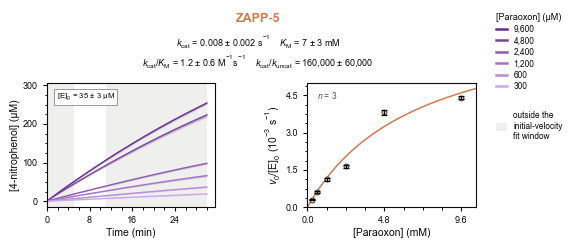

{'Vmax_uM_per_s': 0.2746849917793892,
 'Vmax_err_uM_per_s': 0.06371830939165542,
 'Km_uM': 6854.997936221105,
 'Km_err_uM': 2939.671948918158,
 'kcat_per_s': 0.007893246890212334,
 'kcat_err_per_s': 0.0018309859020590638,
 'kcat_over_Km_per_uM_per_s': 1.1514586822127587e-06,
 'kcat_over_Km_err_per_uM_per_s': np.float64(5.613996184179299e-07),
 'kuncat_per_s': 1.1659878914507422e-07,
 'kcat_over_kuncat': 67695.78782153064,
 'MM_R2': 0.9644281335891103,
 'kuncat_R2': 0.6848239621793957,
 'enzyme_uM': 34.8,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 660),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.010622        0.001260  3
 1             600.0         0.021161        0.002537  3
 2            1200.0         0.038820        0.003257  3
 3            2400.0         0.057056        0.003966  3
 4            4800.0         0.132742        0.006368  3
 5            9600.0         0.153439        0.004380  3,
 '_bg_by_row':   

In [14]:
run_kinetics_PTE_RFd3(
    'ZAPP-5',
    file_prefix = '260731_p1F6_34pt8uM',
    enzyme_uM   = 34.8,
    enzyme_cols = [1, 2, 3], bg_cols = [4],
    time_range_seconds = (300, 660),
    scaffold    = 'PTE_i2_s1',
    plate_id    = 'p1F6',
    plot_name   = 'kinetics_ZAPP5_p1F6',
)

### II.III.F. R2 p1D9, scaffold 1

[E]<sub>0</sub> = 44.6 µM, paraoxon 0.3–9.6 mM, 25 mM NaHCO₃, 1 % MeOH, 405 nm.

Parsing [raw_wetlab_data/260804_ZAPP1strp_24uM__p1D9_44pt6uM__p1H4_39pt1uM__80uL_1prctMeOH_trip_blank__leg_buff__9pt6mMpxn_serialDIL_30m_25finalbica.xlsx] Measured at [2026-08-05 17:07:23]...
Parsing [raw_wetlab_data/260804_ZAPP1strp_24uM__p1D9_44pt6uM__p1H4_39pt1uM__80uL_1prctMeOH_trip_blank__leg_buff__9pt6mMpxn_serialDIL_30m_25finalbica.xlsx] Measured at [2026-08-05 17:07:23]...


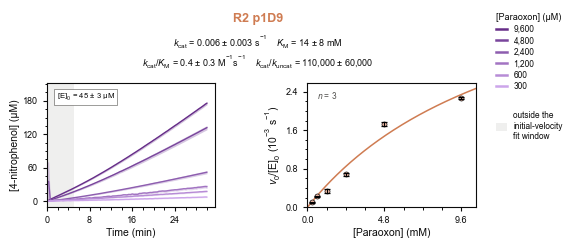

{'Vmax_uM_per_s': 0.25187455887016486,
 'Vmax_err_uM_per_s': 0.09125361008028017,
 'Km_uM': 13568.389171450588,
 'Km_err_uM': 7389.465287326308,
 'kcat_per_s': 0.0056474116338601985,
 'kcat_err_per_s': 0.0020460450690645776,
 'kcat_over_Km_per_uM_per_s': 4.162182822514397e-07,
 'kcat_over_Km_err_per_uM_per_s': np.float64(2.7225211863684874e-07),
 'kuncat_per_s': 1.5709974170863582e-07,
 'kcat_over_kuncat': 35947.937103131204,
 'MM_R2': 0.9732121192275354,
 'kuncat_R2': 0.9657235867967073,
 'enzyme_uM': 44.6,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 20000),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.004370        0.000742  3
 1             600.0         0.010084        0.001292  3
 2            1200.0         0.015369        0.003102  3
 3            2400.0         0.030626        0.002533  3
 4            4800.0         0.076900        0.003047  3
 5            9600.0         0.101116        0.002237  3,
 '_bg_by_ro

In [15]:
run_kinetics_PTE_RFd3(
    'R2 p1D9',
    file_prefix = '260804_ZAPP1strp_24uM',
    enzyme_uM   = 44.6,
    enzyme_cols = [5, 6, 7], bg_cols = [8],
    scaffold    = 'PTE_i2_s1',
    plate_id    = 'p1D9',
    plot_name   = 'kinetics_R2_p1D9',
)

### II.III.G. R2 p1H4, scaffold 1

[E]<sub>0</sub> = 39.1 µM, paraoxon 0.3–9.6 mM, 25 mM NaHCO₃, 1 % MeOH, 405 nm.

Parsing [raw_wetlab_data/260804_ZAPP1strp_24uM__p1D9_44pt6uM__p1H4_39pt1uM__80uL_1prctMeOH_trip_blank__leg_buff__9pt6mMpxn_serialDIL_30m_25finalbica.xlsx] Measured at [2026-08-05 17:07:23]...
Parsing [raw_wetlab_data/260804_ZAPP1strp_24uM__p1D9_44pt6uM__p1H4_39pt1uM__80uL_1prctMeOH_trip_blank__leg_buff__9pt6mMpxn_serialDIL_30m_25finalbica.xlsx] Measured at [2026-08-05 17:07:23]...


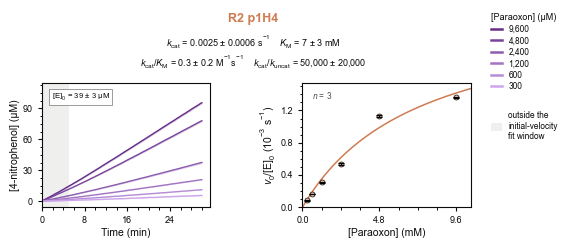

{'Vmax_uM_per_s': 0.09781761546563617,
 'Vmax_err_uM_per_s': 0.019160802080854602,
 'Km_uM': 7355.668145278195,
 'Km_err_uM': 2603.9683484628977,
 'kcat_per_s': 0.0025017292957963213,
 'kcat_err_per_s': 0.0004900460890244143,
 'kcat_over_Km_per_uM_per_s': 3.401090487479713e-07,
 'kcat_over_Km_err_per_uM_per_s': np.float64(1.3760430344902305e-07),
 'kuncat_per_s': 1.1653363596040756e-07,
 'kcat_over_kuncat': 21467.872989445612,
 'MM_R2': 0.9774093191228842,
 'kuncat_R2': 0.8958565031347829,
 'enzyme_uM': 39.1,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 20000),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.003307        0.000484  3
 1             600.0         0.006398        0.000208  3
 2            1200.0         0.012001        0.000432  3
 3            2400.0         0.021129        0.000893  3
 4            4800.0         0.044257        0.000895  3
 5            9600.0         0.053323        0.000457  3,
 '_bg_by_r

In [16]:
run_kinetics_PTE_RFd3(
    'R2 p1H4',
    file_prefix = '260804_ZAPP1strp_24uM',
    enzyme_uM   = 39.1,
    enzyme_cols = [9, 10, 11], bg_cols = [12],
    scaffold    = 'PTE_i2_s1',
    plate_id    = 'p1H4',
    plot_name   = 'kinetics_R2_p1H4',
)

## II.IV. ZAPP-1 Active-Site Mutants

Six single-site mutants of ZAPP-1, measured under the same conditions as the
parent so the fits are directly comparable.

### II.IV.A. ZAPP-1 MUT1

[E]<sub>0</sub> = 32.7 µM, paraoxon 0.3–9.6 mM, 25 mM NaHCO₃, 1 % MeOH, 405 nm.

Parsing [raw_wetlab_data/260804_p2H3_4pt6uM__ZAPPmut1_32pt7uM__ZAPPmut2_25pt8uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_30m__25finalbicarb.xlsx] Measured at [2026-08-05 17:23:35]...
Parsing [raw_wetlab_data/260804_p2H3_4pt6uM__ZAPPmut1_32pt7uM__ZAPPmut2_25pt8uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_30m__25finalbicarb.xlsx] Measured at [2026-08-05 17:23:35]...


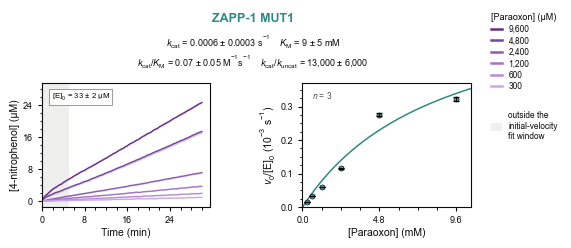

{'Vmax_uM_per_s': 0.0211487018362345,
 'Vmax_err_uM_per_s': 0.006440045299811077,
 'Km_uM': 8716.396139810444,
 'Km_err_uM': 4546.261175124832,
 'kcat_per_s': 0.0006467492916279663,
 'kcat_err_per_s': 0.0001969432813397883,
 'kcat_over_Km_per_uM_per_s': 7.41991622746544e-08,
 'kcat_over_Km_err_per_uM_per_s': np.float64(4.48134192914071e-08),
 'kuncat_per_s': 2.0385581658066643e-07,
 'kcat_over_kuncat': 3172.581986994938,
 'MM_R2': 0.9605853723641888,
 'kuncat_R2': 0.8629974402993233,
 'enzyme_uM': 32.7,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 20000),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.000531        0.000005  3
 1             600.0         0.001074        0.000041  3
 2            1200.0         0.001989        0.000035  3
 3            2400.0         0.003794        0.000119  3
 4            4800.0         0.009023        0.000315  3
 5            9600.0         0.010555        0.000323  3,
 '_bg_by_row':  

In [17]:
run_kinetics_PTE_RFd3(
    'ZAPP-1 MUT1',
    file_prefix = '260804_p2H3_4pt6uM',
    enzyme_uM   = 32.7,
    enzyme_cols = [5, 6, 7], bg_cols = [8],
    scaffold    = 'PET_i1',
    plate_id    = 'p1D1',
    plot_name   = 'kinetics_ZAPP1_MUT1',
)

### II.IV.B. ZAPP-1 MUT2

[E]<sub>0</sub> = 25.8 µM, paraoxon 0.3–9.6 mM, 25 mM NaHCO₃, 1 % MeOH, 405 nm.

Parsing [raw_wetlab_data/260804_p2H3_4pt6uM__ZAPPmut1_32pt7uM__ZAPPmut2_25pt8uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_30m__25finalbicarb.xlsx] Measured at [2026-08-05 17:23:35]...
Parsing [raw_wetlab_data/260804_p2H3_4pt6uM__ZAPPmut1_32pt7uM__ZAPPmut2_25pt8uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_30m__25finalbicarb.xlsx] Measured at [2026-08-05 17:23:35]...


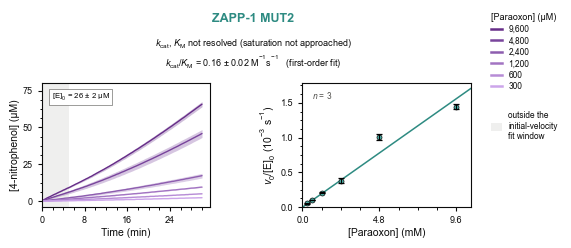

{'Vmax_uM_per_s': 0.1188211729739902,
 'Vmax_err_uM_per_s': 0.05443729188165401,
 'Km_uM': 20340.497499656172,
 'Km_err_uM': 12641.984359725566,
 'kcat_per_s': 0.004605471820697295,
 'kcat_err_per_s': 0.002109972553552481,
 'kcat_over_Km_per_uM_per_s': 2.2641883861371355e-07,
 'kcat_over_Km_err_per_uM_per_s': np.float64(1.7482425062898013e-07),
 'kuncat_per_s': 8.695975561603873e-08,
 'kcat_over_kuncat': 52960.9563420607,
 'MM_R2': 0.979525748394896,
 'kuncat_R2': 0.9391608753461927,
 'enzyme_uM': 25.8,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 20000),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.001411        0.000071  3
 1             600.0         0.002806        0.000068  3
 2            1200.0         0.005357        0.000254  3
 3            2400.0         0.009887        0.001374  3
 4            4800.0         0.026127        0.001950  3
 5            9600.0         0.037210        0.001640  3,
 '_bg_by_row':  

In [18]:
run_kinetics_PTE_RFd3(
    'ZAPP-1 MUT2',
    file_prefix = '260804_p2H3_4pt6uM',
    enzyme_uM   = 25.8,
    enzyme_cols = [9, 10, 11], bg_cols = [12],
    scaffold    = 'PET_i1',
    plate_id    = 'p1D1',
    plot_name   = 'kinetics_ZAPP1_MUT2',
)

### II.IV.C. ZAPP-1 MUT3

[E]<sub>0</sub> = 28.1 µM, paraoxon 0.3–9.6 mM, 25 mM NaHCO₃, 1 % MeOH, 405 nm.

Parsing [raw_wetlab_data/260804_ZAPPmut3_28pt1uM__ZAPPmut4_18pt7uM__ZAPPmut5_39pt5uM__80uL_1prtMeOH_trip_blk__leg_buff__9pt6mMpxn_serDIL_30m__25bica.xlsx] Measured at [2026-08-05 17:51:37]...
Parsing [raw_wetlab_data/260804_ZAPPmut3_28pt1uM__ZAPPmut4_18pt7uM__ZAPPmut5_39pt5uM__80uL_1prtMeOH_trip_blk__leg_buff__9pt6mMpxn_serDIL_30m__25bica.xlsx] Measured at [2026-08-05 17:51:37]...


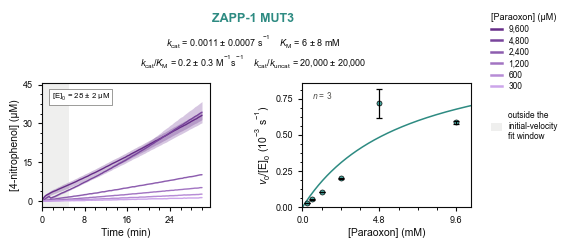

{'Vmax_uM_per_s': 0.031792402206235505,
 'Vmax_err_uM_per_s': 0.01880341233432038,
 'Km_uM': 6422.680383472373,
 'Km_err_uM': 7172.248056275914,
 'kcat_per_s': 0.0011314022137450357,
 'kcat_err_per_s': 0.0006691605812925402,
 'kcat_over_Km_per_uM_per_s': 1.7615732781231e-07,
 'kcat_over_Km_err_per_uM_per_s': np.float64(2.226031097499883e-07),
 'kuncat_per_s': 1.2305003753628685e-07,
 'kcat_over_kuncat': 9194.651512490524,
 'MM_R2': 0.8126104409617692,
 'kuncat_R2': 0.7828689328103343,
 'enzyme_uM': 28.1,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 20000),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.000772        0.000039  3
 1             600.0         0.001523        0.000067  3
 2            1200.0         0.002967        0.000058  3
 3            2400.0         0.005602        0.000083  3
 4            4800.0         0.020152        0.005012  3
 5            9600.0         0.016506        0.000554  3,
 '_bg_by_row': 

In [19]:
run_kinetics_PTE_RFd3(
    'ZAPP-1 MUT3',
    file_prefix = '260804_ZAPPmut3_28pt1uM',
    enzyme_uM   = 28.1,
    enzyme_cols = [1, 2, 3], bg_cols = [4],
    scaffold    = 'PET_i1',
    plate_id    = 'p1D1',
    plot_name   = 'kinetics_ZAPP1_MUT3',
)

### II.IV.D. ZAPP-1 MUT4

[E]<sub>0</sub> = 18.7 µM, paraoxon 0.3–9.6 mM, 25 mM NaHCO₃, 1 % MeOH, 405 nm.

Parsing [raw_wetlab_data/260804_ZAPPmut3_28pt1uM__ZAPPmut4_18pt7uM__ZAPPmut5_39pt5uM__80uL_1prtMeOH_trip_blk__leg_buff__9pt6mMpxn_serDIL_30m__25bica.xlsx] Measured at [2026-08-05 17:51:37]...
Parsing [raw_wetlab_data/260804_ZAPPmut3_28pt1uM__ZAPPmut4_18pt7uM__ZAPPmut5_39pt5uM__80uL_1prtMeOH_trip_blk__leg_buff__9pt6mMpxn_serDIL_30m__25bica.xlsx] Measured at [2026-08-05 17:51:37]...


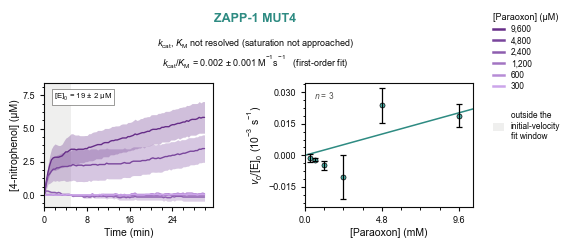

{'Vmax_uM_per_s': 0.010696729003961302,
 'Vmax_err_uM_per_s': 0.530392877023858,
 'Km_uM': 259200.0000176161,
 'Km_err_uM': 13256420.100513645,
 'kcat_per_s': 0.000572017593794722,
 'kcat_err_per_s': 0.02836325545582128,
 'kcat_over_Km_per_uM_per_s': 2.2068580006012567e-09,
 'kcat_over_Km_err_per_uM_per_s': np.float64(1.5720356772649092e-07),
 'kuncat_per_s': 1.3030428643110277e-07,
 'kcat_over_kuncat': 4389.860145523081,
 'MM_R2': 0.48731995673615436,
 'kuncat_R2': 0.9262841080143924,
 'enzyme_uM': 18.7,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 20000),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0        -0.000024        0.000067  3
 1             600.0        -0.000039        0.000027  3
 2            1200.0        -0.000088        0.000068  3
 3            2400.0        -0.000191        0.000334  3
 4            4800.0         0.000444        0.000265  3
 5            9600.0         0.000353        0.000180  3,
 '_bg_by_row':

In [20]:
run_kinetics_PTE_RFd3(
    'ZAPP-1 MUT4',
    file_prefix = '260804_ZAPPmut3_28pt1uM',
    enzyme_uM   = 18.7,
    enzyme_cols = [5, 6, 7], bg_cols = [8],
    scaffold    = 'PET_i1',
    plate_id    = 'p1D1',
    plot_name   = 'kinetics_ZAPP1_MUT4',
)

### II.IV.E. ZAPP-1 MUT5

[E]<sub>0</sub> = 39.5 µM, paraoxon 0.3–9.6 mM, 25 mM NaHCO₃, 1 % MeOH, 405 nm.

Parsing [raw_wetlab_data/260804_ZAPPmut3_28pt1uM__ZAPPmut4_18pt7uM__ZAPPmut5_39pt5uM__80uL_1prtMeOH_trip_blk__leg_buff__9pt6mMpxn_serDIL_30m__25bica.xlsx] Measured at [2026-08-05 17:51:37]...
Parsing [raw_wetlab_data/260804_ZAPPmut3_28pt1uM__ZAPPmut4_18pt7uM__ZAPPmut5_39pt5uM__80uL_1prtMeOH_trip_blk__leg_buff__9pt6mMpxn_serDIL_30m__25bica.xlsx] Measured at [2026-08-05 17:51:37]...


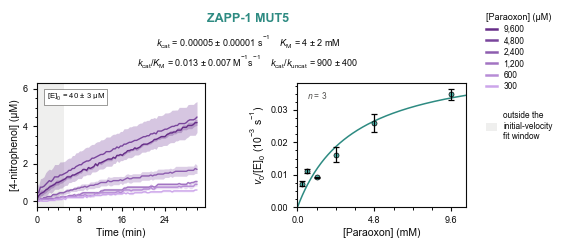

{'Vmax_uM_per_s': 0.001810475175925536,
 'Vmax_err_uM_per_s': 0.0003401553865792014,
 'Km_uM': 3507.6023128035567,
 'Km_err_uM': 1516.408375666773,
 'kcat_per_s': 4.583481458039332e-05,
 'kcat_err_per_s': 8.611528774156998e-06,
 'kcat_over_Km_per_uM_per_s': 1.306727801298502e-08,
 'kcat_over_Km_err_per_uM_per_s': np.float64(6.159674153094818e-09),
 'kuncat_per_s': 8.999637725484654e-08,
 'kcat_over_kuncat': 509.296218119991,
 'MM_R2': 0.921078495341493,
 'kuncat_R2': 0.5957317378963398,
 'enzyme_uM': 39.5,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 20000),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.000288        0.000045  3
 1             600.0         0.000437        0.000041  3
 2            1200.0         0.000365        0.000015  3
 3            2400.0         0.000640        0.000160  3
 4            4800.0         0.001024        0.000198  3
 5            9600.0         0.001377        0.000116  3,
 '_bg_by_row'

In [21]:
run_kinetics_PTE_RFd3(
    'ZAPP-1 MUT5',
    file_prefix = '260804_ZAPPmut3_28pt1uM',
    enzyme_uM   = 39.5,
    enzyme_cols = [9, 10, 11], bg_cols = [12],
    scaffold    = 'PET_i1',
    plate_id    = 'p1D1',
    plot_name   = 'kinetics_ZAPP1_MUT5',
)

### II.IV.F. ZAPP-1 MUT6

[E]<sub>0</sub> = 23.2 µM, paraoxon 0.3–9.6 mM, 25 mM NaHCO₃, 1 % MeOH, 405 nm.

Parsing [raw_wetlab_data/260804_ZAPPmut6_23pt2uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_30m__25finalbicarb_after3hr.xlsx] Measured at [2026-08-05 18:06:21]...


Parsing [raw_wetlab_data/260804_ZAPPmut6_23pt2uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_30m__25finalbicarb_after3hr.xlsx] Measured at [2026-08-05 18:06:21]...


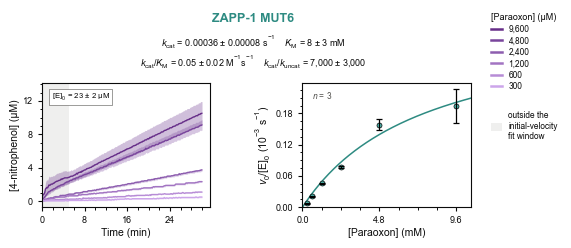

{'Vmax_uM_per_s': 0.008384741557059908,
 'Vmax_err_uM_per_s': 0.001580548464889252,
 'Km_uM': 7627.859083711963,
 'Km_err_uM': 2568.603196725708,
 'kcat_per_s': 0.00036141127401120296,
 'kcat_err_per_s': 6.812708900384708e-05,
 'kcat_over_Km_per_uM_per_s': 4.73804340175787e-08,
 'kcat_over_Km_err_per_uM_per_s': np.float64(1.8284612535968148e-08),
 'kuncat_per_s': 9.04080299218937e-08,
 'kcat_over_kuncat': 3997.5572338368324,
 'MM_R2': 0.9806249766899895,
 'kuncat_R2': 0.607524714380384,
 'enzyme_uM': 23.2,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 20000),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.000167        0.000037  3
 1             600.0         0.000484        0.000015  3
 2            1200.0         0.001059        0.000059  3
 3            2400.0         0.001792        0.000058  3
 4            4800.0         0.003670        0.000424  3
 5            9600.0         0.004512        0.001330  3,
 '_bg_by_row'

In [22]:
run_kinetics_PTE_RFd3(
    'ZAPP-1 MUT6',
    file_prefix = '260804_ZAPPmut6_23pt2uM',
    enzyme_uM   = 23.2,
    enzyme_cols = [1, 2, 3], bg_cols = [4],
    scaffold    = 'PET_i1',
    plate_id    = 'p1D1',
    plot_name   = 'kinetics_ZAPP1_MUT6',
)

## II.V. Tagless ZAPP-1 comparison

Supplementary tagless construct analysis in addition to the original 18 paper kinetics entries. The tagless protein shares the ZAPP-3/ZAPP-4 plate: enzyme columns 9–11, background column 12, 23.4 µM enzyme. High-concentration traces exceed the detector's linear range; section V includes the shorter-window sensitivity check.

The final [tagless SI figure](wetlab_data_plots/paper_figures/png/PTE__v2SI__ZAPP1_tagless.png), [source data and sequences](supplemental_data/ZAPP1_tagless/) and [intact-mass images](mass_spectrometry/) are deposited alongside this analysis.


Parsing [raw_wetlab_data/260731_p2E3_28pt9uM__p2G1_27pt5uM__ZAPP1tagless_23pt4uM_80uL_1prctMeOH_trip_blak__legacy_buf_9pt6mMpxn_serialDIL_30m_25bic.xlsx] Measured at [2026-07-31 21:24:14]...
Parsing [raw_wetlab_data/260731_p2E3_28pt9uM__p2G1_27pt5uM__ZAPP1tagless_23pt4uM_80uL_1prctMeOH_trip_blak__legacy_buf_9pt6mMpxn_serialDIL_30m_25bic.xlsx] Measured at [2026-07-31 21:24:14]...


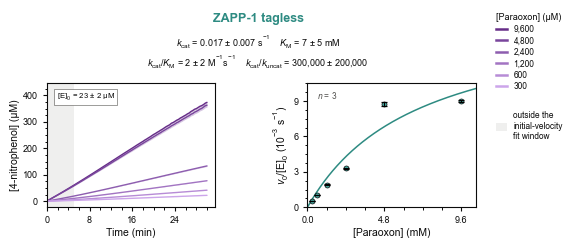

{'Vmax_uM_per_s': 0.39088716907225207,
 'Vmax_err_uM_per_s': 0.140600118112634,
 'Km_uM': 6938.667245187848,
 'Km_err_uM': 4595.920746471152,
 'kcat_per_s': 0.01670457987488257,
 'kcat_err_per_s': 0.006008552056095471,
 'kcat_over_Km_per_uM_per_s': 2.407462310066482e-06,
 'kcat_over_Km_err_per_uM_per_s': np.float64(1.8145718814082797e-06),
 'kuncat_per_s': 5.968639922949251e-08,
 'kcat_over_kuncat': 279872.4682762975,
 'MM_R2': 0.9241918937896412,
 'kuncat_R2': 0.39755835335126877,
 'enzyme_uM': 23.4,
 'signal_per_uM': 0.00667808,
 'time_range_seconds': (300, 20000),
 '_agg':    concentration_uM  v_mean_uM_per_s  v_std_uM_per_s  n
 0             300.0         0.012926        0.000163  3
 1             600.0         0.024331        0.000257  3
 2            1200.0         0.044858        0.000308  3
 3            2400.0         0.076891        0.002001  3
 4            4800.0         0.204263        0.006795  3
 5            9600.0         0.210439        0.003295  3,
 '_bg_by_row':    

In [23]:
run_kinetics_PTE_RFd3(
    'ZAPP-1 tagless', file_prefix='260731_p2E3_28pt9uM', enzyme_uM=23.4,
    enzyme_cols=[9, 10, 11], bg_cols=[12], scaffold='PET_i1', plate_id='p1D1',
    plot_name='kinetics_ZAPP1_tagless',
)


# **III. SUMMARY OF FITTED KINETIC PARAMETERS**

## III.I. Combined Table

Every fit recorded in section II, with the condition-matched
*k*<sub>uncat</sub> from section I.II and the derived ratios. Errors on the
ratios propagate the relative errors of the two terms in quadrature.

The table is assembled from the fits held in `FITS`, so it always reflects the
cells actually run above rather than a transcribed copy. Run section II in full
before this cell.

In [24]:
############################################
### SUMMARY TABLE OF ALL FITTED DESIGNS  ###
############################################

### CHECK EVERYTHING UPSTREAM HAS BEEN RUN ###
if not FITS:
    raise RuntimeError("FITS is empty -- run the kinetics cells in section II first.")
if 'KUNCAT' not in globals():
    raise RuntimeError("KUNCAT is not defined -- run section I.II first.")

### ASSEMBLE ###
rows = []
for name, f in FITS.items():
    mm = f['mm']
    rows.append({
        "design":            name,
        "plate ID":          f.get('plate_id'),
        "scaffold":          f.get('scaffold'),
        "condition":         f['condition'],
        "[E]0 (uM)":         f['enzyme_uM'],
        "kcat (s-1)":        mm['kcat_per_s'],
        "kcat sd":           mm['kcat_err_per_s'],
        "Km (uM)":           mm['Km_uM'],
        "Km sd":             mm['Km_err_uM'],
        "kcat/Km (M-1 s-1)": mm['kcat_over_Km_per_uM_per_s'] * 1e6,
        "kcat/Km sd":        mm['kcat_over_Km_err_per_uM_per_s'] * 1e6,
    })
summary_df = pd.DataFrame(rows)

### CONDITION-MATCHED UNCATALYZED RATE ###
summary_df["kuncat (s-1)"]  = summary_df["condition"].map(lambda c: KUNCAT[c]["k"])
summary_df["kuncat sd"]     = summary_df["condition"].map(lambda c: KUNCAT[c]["err"])

### DERIVED RATIOS (relative errors added in quadrature) ###
def _rel(a, sa, b, sb):
    return np.hypot(sa / a, sb / b)

summary_df["kcat/kuncat"] = summary_df["kcat (s-1)"] / summary_df["kuncat (s-1)"]
summary_df["kcat/kuncat sd"] = summary_df["kcat/kuncat"] * _rel(
    summary_df["kcat (s-1)"], summary_df["kcat sd"],
    summary_df["kuncat (s-1)"], summary_df["kuncat sd"])
summary_df["(kcat/Km)/kuncat (M-1)"] = summary_df["kcat/Km (M-1 s-1)"] / summary_df["kuncat (s-1)"]
summary_df["(kcat/Km)/kuncat sd"] = summary_df["(kcat/Km)/kuncat (M-1)"] * _rel(
    summary_df["kcat/Km (M-1 s-1)"], summary_df["kcat/Km sd"],
    summary_df["kuncat (s-1)"], summary_df["kuncat sd"])

### PAPER UNCERTAINTY BUDGET AND REPORTING STATUS ###
# Keep fit-only errors above, and expose total errors separately. The original
# paper table stores rounded inputs; freshly computed values are kept full precision.
from kinetics_pte_rfd3 import paper_style
_paper = paper_style().TAB
for _i, _row in summary_df.iterrows():
    _name = _row['design']
    _full = result_row(_name, FITS[_name]['mm'], _row['condition'], KUNCAT[_row['condition']])
    for _col in ['kcat sd (total)', 'kcat/Km sd (total)', 'kcat/kuncat sd', '(kcat/Km)/kuncat sd (M-1)']:
        summary_df.loc[_i, _col] = _full[_col]
    _reported = _paper.loc[_name] if _name in _paper.index else _full
    for _col in ['kcat (reported)', 'Km (reported, mM)', 'kcat/Km (reported)']:
        summary_df.loc[_i, _col] = _reported[_col]
    if _name in ('ZAPP-1 MUT2', 'ZAPP-1 MUT4'):
        summary_df.loc[_i, 'kcat/Km (reported)'] = _paper.loc[_name, 'kcat/Km chord (reported)']
        summary_df.loc[_i, 'reporting model'] = 'first-order; kcat and KM not resolved'
    else:
        summary_df.loc[_i, 'reporting model'] = 'Michaelis-Menten'
summary_df['(kcat/Km)/kuncat sd'] = summary_df['(kcat/Km)/kuncat sd (M-1)']
validation_df = validate_reference(FITS, KUNCAT)

### WRITE ###
summary_csv = os.path.join(wetlab_data_plots_dir, "kinetics_summary.csv")
summary_df.to_csv(summary_csv, index=False, float_format="%.6g")
print(f"{len(summary_df)} fits -> {os.path.relpath(summary_csv)}\n")

### DISPLAY PAPER-REPORTED PARAMETERS ###
# Raw nonlinear-fit diagnostics, fit-only errors and total errors stay in the
# CSV. Show n.d. and the first-order estimates for unresolved paper mutants.
_show = ["design", "scaffold", "condition", "[E]0 (uM)",
         "kcat (reported)", "Km (reported, mM)", "kcat/Km (reported)", "reporting model"]
summary_df[_show]


Paper reference: 234 numerical checks passed at stored precision.
19 fits -> wetlab_data_plots/kinetics_summary.csv



,design,scaffold,condition,[E]0 (uM),kcat (reported),"Km (reported, mM)",kcat/Km (reported),reporting model
0,ZAPP-1,PET_i1,+25 mM NaHCO3,24.0,(1.5 ± 0.3) x 10^-2,8 ± 2,2.0 ± 0.6,Michaelis-Menten
1,ZAPP-1 (no NaHCO3),PET_i1,no NaHCO3,37.3,(1.3 ± 0.2) x 10^-3,2.6 ± 0.7,0.5 ± 0.2,Michaelis-Menten
2,R1 p1D7,PET_i1,+25 mM NaHCO3,21.3,(3.2 ± 0.3) x 10^-3,1.5 ± 0.4,2.2 ± 0.6,Michaelis-Menten
3,R1 p1D8,PET_i1,+25 mM NaHCO3,26.1,(2.9 ± 0.3) x 10^-3,1.5 ± 0.4,1.9 ± 0.5,Michaelis-Menten
4,R1 p1E10,PET_i1,+25 mM NaHCO3,15.3,(1.9 ± 0.3) x 10^-3,2.5 ± 0.8,0.8 ± 0.3,Michaelis-Menten
5,ZAPP-2,PTE_i2_s3,+25 mM NaHCO3,26.6,(2.3 ± 0.6) x 10^-2,6 ± 3,4 ± 3,Michaelis-Menten
6,R2 p2B12,PTE_i2_s3,+25 mM NaHCO3,10.3,(3.9 ± 0.6) x 10^-3,3 ± 2,1.2 ± 0.5,Michaelis-Menten
7,ZAPP-3,PTE_i2_s7,+25 mM NaHCO3,27.5,(1.0 ± 0.3) x 10^-2,6 ± 4,2 ± 1,Michaelis-Menten
8,ZAPP-4,PTE_i2_s6,+25 mM NaHCO3,28.9,(1.0 ± 0.2) x 10^-2,3 ± 2,3 ± 2,Michaelis-Menten
9,ZAPP-5,PTE_i2_s1,+25 mM NaHCO3,34.8,(8 ± 2) x 10^-3,7 ± 3,1.2 ± 0.6,Michaelis-Menten


# **IV. ELUATE SCREENING**

## IV.I. Round 1 Eluate Screen (96-Well)

Purified eluate from each design in the first order, one well per design,
followed at 405 nm. 300 µM paraoxon, 1 % MeOH, 200 µM ZnSO<sub>4</sub>,
HEPES elution buffer, 1 h at room temperature.

Each trace is normalized to its own first reading so wells are compared on
change in absorbance rather than absolute signal, which varies with eluate
concentration. The fastest-climbing wells are labeled.

Hits are: D1, D7, D8, E10


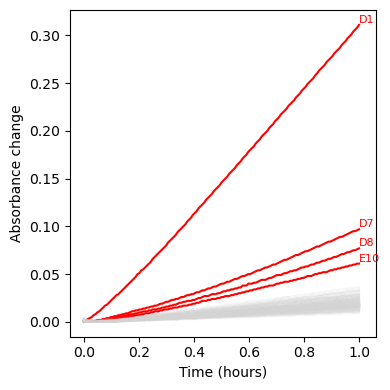

saved wetlab_data_plots/screen_round1_progress_curves.png


In [25]:
###################################################
### ROUND 1 ELUATE SCREEN - PROGRESS CURVES     ###
###################################################

### PROGRESS-CURVE HELPERS ###
# Vendored alongside the kinetics parsers; see Scripts/wetlab_platereader/.
import screening_curves
screening_curves.SAVE_DPI = FIGURE_DPI          # keep it in step with this notebook
from screening_curves import draw_progression_curve_v0

### INPUT ###
screen_r1_file = raw('250919_order1_plate1')
rows, columns  = list("ABCDEFGH"), list(range(1, 13))

### PARAMETERS ###
hit_definition_num = 4        # how many of the fastest wells to label
blank              = []       # wells to treat as blank (none on this plate)
ignore             = []       # wells to leave out entirely
time_start, time_end = 0, 12  # minutes

### OUTPUT ###
screen_r1_plot = os.path.join(wetlab_data_plots_dir, 'screen_round1_progress_curves.png')

### EXECUTION ###
draw_progression_curve_v0(
    screen_r1_file, rows, columns, hit_definition_num, blank,
    time_start, time_end, label=True, start_row=36, ignore=ignore,
    save_path=screen_r1_plot,
)
print(f"saved {os.path.relpath(screen_r1_plot)}")

### IV.I.A. Supplementary-information screening style

The additional view below reproduces the standalone screening panel from the
RFdiffusion3 supplementary-information figure. Colored curves are the designs
characterized by kinetics, with the manuscript scaffold colors and direct labels.
The gray band is the 5th–95th percentile envelope of the other designs. Every
trace is relative to its own first absorbance reading; time is in hours.
The original screening view above is retained. This display performs no new
fitting, hit calling, or filtering.


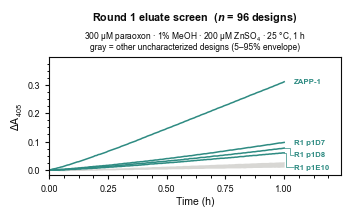

saved Manuscript_Data/Phosphotriesterase_RFdiffusion3_Science_2026/wetlab_data_plots/screen_round1_SI_style.png


In [2]:
from kinetics_pte_rfd3 import plot_screening_PTE_RFd3

screen_r1_si_plot = os.path.join(
    wetlab_data_plots_dir, 'screen_round1_SI_style.png')
plot_screening_PTE_RFd3(1, plot_path=screen_r1_si_plot, dpi=600)
print(f"saved {os.path.relpath(screen_r1_si_plot)}")


## IV.II. Round 2 Eluate Screen (384-Well)

The second order, 192 designs across two 96-well source plates, stamped into a
single 384-well reader plate and read for an hour. 600 µM paraoxon, 1 % MeOH,
50 mM bicarbonate buffer, 60 µL reactions, 405 nm, 25 °C.

Because two source plates are interleaved into one reader plate, the mapping
from reader well back to design is the step most worth checking; IV.II.B tests
it against the designs that were independently sequenced.

### IV.II.A. Assay Constants and Well Mapping

Reader wells are mapped back to their source plate and 96-well position, then
joined to the ordered-design table built from the order FASTA headers. The
mapping carries its own assertions, so a mis-stamped plate fails here rather
than silently mislabeling every design downstream.

In [26]:
##########################################
### ROUND 2 SCREEN - ASSAY CONSTANTS   ###
##########################################

### PLATE / ASSAY ###
EXPECTED_N_DESIGNS      = 192
EXPECTED_N_READER_WELLS = 192
SUBSTRATE_UM       = 600.0     # paraoxon
RXN_VOLUME_UL      = 60.0
COSOLVENT          = '1% (v/v) MeOH'
BUFFER             = '50 mM bicarbonate ("legacy" buffer)'
READ_WAVELENGTH_NM = 405
ASSAY_TEMP_C       = 25

### INITIAL-VELOCITY FIT WINDOW (minutes) ###
FIT_START_MIN = 2.0
FIT_END_MIN   = 15.0

### QC THRESHOLDS ###
ABS_LINEAR_CEILING = 2.0       # absorbance is only trusted below this
DROP_ABS_TOL       = 0.010     # a single-read decrease beyond this is an optical artifact
MIN_FIT_POINTS     = 8

### HIT CALLING ###
HIT_Z_THRESHOLD    = 5.0       # robust z above the inactive population
HIT_FOLD_THRESHOLD = 3.0       # and at least this many fold over background

### FIGURE SIZING (Nature: 89 mm single column, 183 mm double) ###
MM = 1 / 25.4
WIDTH_1COL = 89 * MM
WIDTH_2COL = 183 * MM

### PLOT PALETTE ###
# Okabe-Ito hues, chosen to stay distinguishable under deuteranopia and protanopia.
SCAFFOLD_COLORS = {
    1:  '#0072B2',   # blue
    2:  '#56B4E9',   # sky blue
    3:  '#D55E00',   # vermillion
    4:  '#E69F00',   # orange
    5:  '#A6761D',   # dark gold
    6:  '#009E73',   # bluish green
    7:  '#CC79A7',   # reddish purple
    8:  '#5D3A9B',   # violet
    9:  '#66A61E',   # olive
    10: '#A65628',   # brown
    11: '#E7298A',   # magenta
}
BACKGROUND_TRACE_COLOR = '#b8b8b8'   # inactive progress curves
FIT_WINDOW_COLOR       = '#f2c94c'   # shaded initial-rate window

def style_science_axes(ax, title=None, x_label=None, y_label=None,
                       title_size=7.5, label_size=7, tick_size=6, spine_width=0.6):
    """Boxed, inward-ticked axes - the house style, scaled to publication point sizes."""
    if title is not None:
        ax.set_title(title, fontsize=title_size, weight='semibold')
    if x_label is not None:
        ax.set_xlabel(x_label, fontsize=label_size, weight='semibold')
    if y_label is not None:
        ax.set_ylabel(y_label, fontsize=label_size, weight='semibold')
    ax.tick_params(axis='both', which='major', labelsize=tick_size,
                   direction='in', length=2.6, width=spine_width, top=True, right=True)
    ax.tick_params(axis='both', which='minor', direction='in', length=1.5,
                   width=spine_width * 0.83, top=True, right=True)
    for side in ['left', 'right', 'top', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(spine_width)
        ax.spines[side].set_edgecolor('black')

print(f"{EXPECTED_N_DESIGNS} designs, {SUBSTRATE_UM:g} uM paraoxon, {BUFFER}, "
      f"{READ_WAVELENGTH_NM} nm, {ASSAY_TEMP_C} C")
print(f"initial rates fitted over {FIT_START_MIN:g}-{FIT_END_MIN:g} min")

192 designs, 600 uM paraoxon, 50 mM bicarbonate ("legacy" buffer), 405 nm, 25 C
initial rates fitted over 2-15 min


In [27]:
####################################################################
### MAP READER WELLS TO ORDERED DESIGNS AND SCAFFOLDS            ###
####################################################################

### INPUTS ###
platereader_csv      = raw('260525_i3smw')
order_fasta          = raw('260514__ARuder')
design_decisions_csv = raw('design_decisions')

expected_n_designs      = EXPECTED_N_DESIGNS
expected_n_reader_wells = EXPECTED_N_READER_WELLS

#####################
### HELPER LOGIC  ###
#####################

DESIGN_NAME_RE = re.compile(
    r'(?P<design_id>ZAPP_i3_AR_pte_(?P<design_index>\d+))'
    r'_scaffold_(?P<scaffold>\d+)'
    r'____Plate(?P<plate_number>\d)__(?P<well_position>[A-H]\d{1,2})'
    r'____(?P<parent>.+?)(?:\.pdb)?$'
)

def parse_design_name(name):
    """Pull design id, scaffold and plate position out of an ordered design name."""
    match = DESIGN_NAME_RE.match(str(name).strip())
    if match is None:
        raise ValueError(f'Could not parse ordered design name: {name}')
    fields = match.groupdict()
    return {
        'design_id':     fields['design_id'],
        'design_index':  int(fields['design_index']),
        'scaffold':      int(fields['scaffold']),
        'plate_number':  int(fields['plate_number']),
        'well_position': fields['well_position'].upper(),
        'parent':        fields['parent'],
    }

def load_design_table(fasta_path):
    """Build the ordered-design table from the FASTA headers sent to the vendor."""
    headers = [line[1:].strip() for line in Path(fasta_path).read_text().splitlines()
               if line.startswith('>')]
    if len(headers) != expected_n_designs:
        raise ValueError(f'Expected {expected_n_designs} FASTA records, found {len(headers)}.')

    design_df = pd.DataFrame([parse_design_name(h) for h in headers])
    design_df['source_well'] = ('P' + design_df['plate_number'].astype(str)
                                + design_df['well_position'])
    # the ORI_* token identifies the diffusion parent that defines each scaffold family
    design_df['ori_family'] = design_df['parent'].str.extract(r'(ORI_\d+_C\d+_i_\d+_model_\d+)')

    if design_df['design_id'].duplicated().any():
        raise ValueError('Duplicate design IDs in the order FASTA.')
    if design_df.duplicated(['plate_number', 'well_position']).any():
        raise ValueError('Duplicate plate/well positions in the order FASTA.')
    if not design_df['plate_number'].isin([1, 2]).all():
        raise ValueError('Found a plate number outside {1, 2}.')
    if not design_df['well_position'].str.fullmatch(r'[A-H](?:[1-9]|1[0-2])').all():
        raise ValueError('Found an invalid 96-well position.')

    # each scaffold must correspond to exactly one diffusion parent
    family_counts = design_df.groupby('scaffold')['ori_family'].nunique()
    if (family_counts != 1).any():
        raise ValueError('A scaffold maps to more than one ORI parent family.')
    return design_df

def map_reader_well_to_plate_well(reader_well):
    """384-well reader position -> (source plate number, 96-well position)."""
    match = re.fullmatch(r'([A-H])(\d{1,2})', str(reader_well))
    if match is None:
        raise ValueError(f'Invalid reader well label: {reader_well}')

    reader_row = match.group(1)
    reader_col = int(match.group(2))
    if reader_col < 1 or reader_col > 24:
        raise ValueError(f'Reader well column outside 1-24: {reader_well}')

    reader_row_idx = 'ABCDEFGH'.index(reader_row)
    plate_number = 1 if reader_row_idx < 4 else 2
    row_pairs = [('A', 'B'), ('C', 'D'), ('E', 'F'), ('G', 'H')]
    row_pair = row_pairs[reader_row_idx % 4]
    well_row = row_pair[0] if reader_col % 2 == 1 else row_pair[1]
    well_col = (reader_col + 1) // 2
    return plate_number, f'{well_row}{well_col}'

def get_reader_well_columns(df):
    well_cols = [col for col in df.columns if re.fullmatch(r'[A-H](?:[1-9]|1\d|2[0-4])', str(col))]
    if len(well_cols) != expected_n_reader_wells:
        raise ValueError(f'Expected {expected_n_reader_wells} reader wells, found {len(well_cols)}.')
    return well_cols

def build_reader_map(well_cols):
    """Reader-well -> plate/well table, with the mapping's own unit tests."""
    example_expectations = {
        'A1':  (1, 'A1'),
        'A2':  (1, 'B1'),
        'B5':  (1, 'C3'),
        'E4':  (2, 'B2'),
        'H24': (2, 'H12'),
    }
    for reader_well, expected in example_expectations.items():
        observed = map_reader_well_to_plate_well(reader_well)
        if observed != expected:
            raise AssertionError(f'{reader_well} mapped to {observed}, expected {expected}.')

    reader_map_df = pd.DataFrame([
        {'reader_well': w, **dict(zip(['plate_number', 'well_position'],
                                      map_reader_well_to_plate_well(w)))}
        for w in well_cols
    ])
    if reader_map_df.duplicated(['plate_number', 'well_position']).any():
        raise ValueError('Reader-well mapping produced duplicate 96-well positions.')
    return reader_map_df

def load_reader_traces(platereader_csv):
    """Return (time_min, raw absorbance frame indexed by reader well)."""
    reader_df = pd.read_csv(platereader_csv)
    well_cols = get_reader_well_columns(reader_df)

    raw_time = pd.to_numeric(reader_df['Time'], errors='coerce')
    if raw_time.isna().any():
        raise ValueError('Plate-reader Time column contains non-numeric values.')
    # the reader writes elapsed time as a fraction of a day
    time_min = (raw_time - raw_time.iloc[0]) * 24 * 60

    abs_df = reader_df[well_cols].apply(pd.to_numeric, errors='coerce')
    if abs_df.isna().any().any():
        raise ValueError('Plate-reader absorbance block contains non-numeric values.')
    return time_min.to_numpy(dtype=float), abs_df, well_cols

#################
### LOAD DATA ###
#################

design_df = load_design_table(order_fasta)
time_min, abs_df, reader_well_cols = load_reader_traces(platereader_csv)
reader_map_df = build_reader_map(reader_well_cols)

well_df = reader_map_df.merge(design_df, on=['plate_number', 'well_position'],
                              how='left', validate='one_to_one')
if well_df['design_id'].isna().any():
    display(well_df[well_df['design_id'].isna()])
    raise ValueError('Some reader wells did not receive a design assignment.')

n_timepoints = len(time_min)
read_interval_min = float(np.median(np.diff(time_min)))

print(f'Reader wells mapped:  {len(well_df)}')
print(f'Designs assigned:     {well_df["design_id"].nunique()}')
print(f'Scaffolds present:    {sorted(well_df["scaffold"].unique())}')
print(f'Timepoints:           {n_timepoints} ({time_min[0]:.2f}-{time_min[-1]:.2f} min, '
      f'{read_interval_min:.2f} min interval)')
print(f'Absorbance range:     {abs_df.values.min():.3f}-{abs_df.values.max():.3f} '
      f'A{READ_WAVELENGTH_NM}')
print()
print('Designs per scaffold:')
display(well_df['scaffold'].value_counts().sort_index().rename('n_designs').to_frame().T)

Reader wells mapped:  192
Designs assigned:     192
Scaffolds present:    [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
Timepoints:           86 (0.00-59.50 min, 0.70 min interval)
Absorbance range:     0.132-3.262 A405

Designs per scaffold:


scaffold,1,2,3,4,5,6,7,8,9,10,11
n_designs,89,20,26,1,8,20,5,10,3,9,1


### IV.II.B. Mapping Validation

Two stamping hypotheses are compared against the designs that were
independently sequenced: the interleaved row-pair mapping used above, and a
plain column-halves alternative. The mapping that puts the sequenced designs
in the right wells is the correct one. Skipped automatically if the sequencing
table is absent.

In [28]:
####################################################################
### VALIDATE THE READER MAPPING AGAINST THE SEQUENCED DESIGNS    ###
####################################################################

### INPUTS ###
validation_fit_start_min = FIT_START_MIN
validation_fit_end_min   = FIT_END_MIN

#####################
### HELPER LOGIC  ###
#####################

def quick_ols_rate(y, t, start_min, end_min):
    """Plain OLS slope over a time window - used only for mapping validation."""
    mask = (t >= start_min) & (t <= end_min)
    return float(np.polyfit(t[mask], y[mask], 1)[0])

def column_halves_mapping(reader_well):
    """Alternative stamping hypothesis: plate 1 = columns 1-12, plate 2 = columns 13-24."""
    row, col = re.fullmatch(r'([A-H])(\d+)', reader_well).groups()
    col = int(col)
    plate = 1 if col <= 12 else 2
    return f'P{plate}{row}{col if col <= 12 else col - 12}'

#################
### LOAD DATA ###
#################

if not Path(design_decisions_csv).exists():
    print(f'Sequencing decisions not found, skipping validation: {os.path.relpath(design_decisions_csv)}')
else:
    decisions_df = pd.read_csv(design_decisions_csv)
    sequenced_wells = sorted(set(decisions_df['design']))

    provisional_rate = pd.Series(
        {w: quick_ols_rate(abs_df[w].to_numpy(float), time_min,
                           validation_fit_start_min, validation_fit_end_min)
         for w in reader_well_cols}
    )

    validation_rows = []
    for label, source_lookup in [
        ('interleaved row-pairs (used here)',
         dict(zip(well_df['reader_well'], well_df['source_well']))),
        ('column halves (alternative)',
         {w: column_halves_mapping(w) for w in reader_well_cols}),
    ]:
        ranked = (pd.DataFrame({'reader_well': list(source_lookup),
                                'source_well': list(source_lookup.values())})
                  .assign(rate=lambda d: provisional_rate[d['reader_well']].to_numpy())
                  .assign(rank=lambda d: d['rate'].rank(ascending=False).astype(int))
                  .set_index('source_well'))
        ranks = ranked.loc[sequenced_wells, 'rank'].sort_values()
        validation_rows.append({
            'mapping': label,
            'ranks_of_sequenced_designs': list(ranks.values),
            'n_in_top_10': int((ranks <= 10).sum()),
            'n_in_top_20': int((ranks <= 20).sum()),
        })

    validation_df = pd.DataFrame(validation_rows)
    print(f'Designs sent for sequencing (n={len(sequenced_wells)}): {sequenced_wells}')
    display(validation_df)

    n_top = validation_df.loc[0, 'n_in_top_10']
    # probability of >= n_top of 8 randomly chosen designs landing in the top 10 of 192
    p_chance = stats.hypergeom.sf(n_top - 1, expected_n_designs, 10, len(sequenced_wells))
    print(f'Interleaved mapping puts {n_top}/{len(sequenced_wells)} sequenced designs in the '
          f'top 10 (p = {p_chance:.2e} by chance).')
    if validation_df.loc[0, 'n_in_top_20'] <= validation_df.loc[1, 'n_in_top_20']:
        raise AssertionError('The interleaved mapping is not better supported than the alternative.')
    print('Mapping confirmed.')

Designs sent for sequencing (n=8): ['P1E12', 'P1F5', 'P1F6', 'P1H10', 'P2B12', 'P2C4', 'P2E3', 'P2G1']


,mapping,ranks_of_sequenced_designs,n_in_top_10,n_in_top_20
0,interleaved row-pairs (used here),"[1, 2, 4, 6, 7, 102, 112, 190]",5,5
1,column halves (alternative),"[23, 54, 79, 122, 131, 155, 165, 169]",0,0


Interleaved mapping puts 5/8 sequenced designs in the top 10 (p = 6.39e-06 by chance).
Mapping confirmed.


### IV.II.C. Initial Rates, QC Flags and Hit Calling

An initial rate is fitted per well over the window set above, after excluding
reads above the absorbance ceiling and wells showing optical artifacts. Hits
are called on a robust z-score against the inactive population combined with a
fold-over-background threshold, so both criteria have to agree.

In [29]:
####################################################################
### FIT INITIAL RATES, FLAG ARTIFACTS AND CALL HITS              ###
####################################################################

### INPUTS ###
fit_start_min      = FIT_START_MIN
fit_end_min        = FIT_END_MIN
abs_linear_ceiling = ABS_LINEAR_CEILING
drop_abs_tol       = DROP_ABS_TOL
min_fit_points     = MIN_FIT_POINTS
hit_z_threshold    = HIT_Z_THRESHOLD
hit_fold_threshold = HIT_FOLD_THRESHOLD

### OUTPUTS ###
rates_csv = os.path.join(wetlab_data_plots_dir, 'round2_screen_initial_rates.csv')

#####################
### HELPER LOGIC  ###
#####################

def robust_sd(values):
    """MAD-based standard deviation estimate."""
    values = np.asarray(values, dtype=float)
    return 1.4826 * float(np.median(np.abs(values - np.median(values))))

def find_drop_artifacts(y, tol):
    """Indices of reads where absorbance falls by more than `tol` in a single step."""
    return np.flatnonzero(np.diff(y) < -tol) + 1

def longest_clean_segment(n_points, break_indices, window_mask):
    """Longest run of in-window reads uninterrupted by an artifact."""
    bounds = [0, *sorted(break_indices), n_points]
    best = None
    for lo, hi in zip(bounds[:-1], bounds[1:]):
        seg = np.zeros(n_points, dtype=bool)
        seg[lo:hi] = True
        seg &= window_mask
        if best is None or seg.sum() > best.sum():
            best = seg
    return best

def fit_initial_rate(y, t):
    """OLS initial rate with artifact-aware segment selection.

    Returns the slope in absorbance units per minute plus the diagnostics needed to
    decide whether to trust it.
    """
    window_mask = (t >= fit_start_min) & (t <= fit_end_min)
    drops = find_drop_artifacts(y, drop_abs_tol)

    fit_mask = window_mask
    segmented = False
    if len(drops) and window_mask[drops].any():
        fit_mask = longest_clean_segment(len(y), drops, window_mask)
        segmented = True

    if fit_mask.sum() < min_fit_points:
        # fall back to the full window rather than fitting a handful of reads
        fit_mask = window_mask
        segmented = False

    x, yy = t[fit_mask], y[fit_mask]
    slope, intercept = np.polyfit(x, yy, 1)
    predicted = slope * x + intercept
    ss_res = float(np.sum((yy - predicted) ** 2))
    ss_tot = float(np.sum((yy - yy.mean()) ** 2))

    return {
        'rate_abs_per_min':  float(slope),
        'fit_intercept_abs': float(intercept),
        'fit_r2':            np.nan if ss_tot == 0 else 1 - ss_res / ss_tot,
        'fit_residual_sd':   float(np.sqrt(ss_res / max(len(x) - 2, 1))),
        'fit_n_points':      int(fit_mask.sum()),
        'fit_first_min':     float(x.min()),
        'fit_last_min':      float(x.max()),
        'fit_segmented':     segmented,
        'initial_abs':       float(y[0]),
        'final_abs':         float(y[-1]),
        'max_abs':           float(y.max()),
        'max_abs_in_window': float(y[window_mask].max()),
        'n_drop_artifacts':  int(len(drops)),
        'first_drop_min':    float(t[drops[0]]) if len(drops) else np.nan,
        'largest_drop_abs':  float(np.diff(y).min()),
    }

#################
### LOAD DATA ###
#################

rate_records = []
for reader_well in reader_well_cols:
    y = abs_df[reader_well].to_numpy(dtype=float)
    rate_records.append({'reader_well': reader_well, **fit_initial_rate(y, time_min)})

rates_df = well_df.merge(pd.DataFrame(rate_records), on='reader_well',
                         how='left', validate='one_to_one')

# >> QC flags
rates_df['flag_optical_artifact'] = rates_df['n_drop_artifacts'] > 0
rates_df['flag_above_linear_range'] = rates_df['max_abs'] > abs_linear_ceiling
rates_df['flag_saturated_in_window'] = rates_df['max_abs_in_window'] > abs_linear_ceiling
rates_df['qc_pass'] = ~(rates_df['flag_optical_artifact'] | rates_df['flag_saturated_in_window'])

# >> background: iteratively trim the active tail to isolate the inactive population
inactive = rates_df.loc[rates_df['qc_pass'], 'rate_abs_per_min'].to_numpy(float)
for _ in range(50):
    center, spread = np.median(inactive), robust_sd(inactive)
    keep = np.abs(inactive - center) <= 3 * spread
    if keep.all():
        break
    inactive = inactive[keep]

background_rate = float(np.median(inactive))
background_sd   = robust_sd(inactive)
n_inactive      = int(len(inactive))

rates_df['rate_corrected_abs_per_min'] = rates_df['rate_abs_per_min'] - background_rate
rates_df['robust_z'] = (rates_df['rate_abs_per_min'] - background_rate) / background_sd
rates_df['fold_over_background'] = rates_df['rate_abs_per_min'] / background_rate

rates_df['is_hit'] = (
    (rates_df['robust_z'] >= hit_z_threshold) &
    (rates_df['fold_over_background'] >= hit_fold_threshold) &
    rates_df['qc_pass']
)
rates_df['activity_rank'] = rates_df['rate_abs_per_min'].rank(ascending=False, method='min').astype(int)
rates_df = rates_df.sort_values('activity_rank').reset_index(drop=True)

limit_of_detection = 3 * background_sd

Path(wetlab_data_plots_dir).mkdir(parents=True, exist_ok=True)
rates_df.to_csv(rates_csv, index=False)

print(f'Fit window:                 {fit_start_min:g}-{fit_end_min:g} min')
print(f'Wells refitted on a segment: {int(rates_df["fit_segmented"].sum())}')
print(f'QC failures:                 {int((~rates_df["qc_pass"]).sum())} '
      f'({int(rates_df["flag_optical_artifact"].sum())} optical artifact, '
      f'{int(rates_df["flag_saturated_in_window"].sum())} above linear range in window)')
print(f'Wells exceeding A{READ_WAVELENGTH_NM} {abs_linear_ceiling:g} at any time: '
      f'{int(rates_df["flag_above_linear_range"].sum())}')
print()
print(f'Inactive population:         n = {n_inactive}')
print(f'Background rate:             {background_rate:.3e} +/- {background_sd:.3e} '
      f'A{READ_WAVELENGTH_NM}/min')
print(f'Limit of detection (3 SD):   {limit_of_detection:.3e} A{READ_WAVELENGTH_NM}/min')
print(f'Dynamic range (max/bkg):     {rates_df["rate_abs_per_min"].max() / background_rate:.0f}-fold')
print()
print(f'Hits (z >= {hit_z_threshold:g} and >= {hit_fold_threshold:g}x background): '
      f'{int(rates_df["is_hit"].sum())} / {len(rates_df)} '
      f'({100 * rates_df["is_hit"].mean():.1f}%)')
print(f'Saved: {os.path.relpath(rates_csv)}')
print()

display_cols = ['activity_rank', 'reader_well', 'source_well', 'design_id', 'scaffold',
                'rate_abs_per_min', 'robust_z', 'fold_over_background', 'fit_r2',
                'max_abs', 'qc_pass', 'is_hit']
print('Top 15 designs by initial rate:')
display(rates_df.head(15)[display_cols])

Fit window:                 2-15 min
Wells refitted on a segment: 9
QC failures:                 12 (12 optical artifact, 0 above linear range in window)
Wells exceeding A405 2 at any time: 3

Inactive population:         n = 130
Background rate:             3.734e-04 +/- 2.192e-04 A405/min
Limit of detection (3 SD):   6.577e-04 A405/min
Dynamic range (max/bkg):     165-fold

Hits (z >= 5 and >= 3x background): 40 / 192 (20.8%)
Saved: wetlab_data_plots/round2_screen_initial_rates.csv

Top 15 designs by initial rate:


,activity_rank,reader_well,source_well,design_id,scaffold,rate_abs_per_min,robust_z,fold_over_background,fit_r2,max_abs,qc_pass,is_hit
0,1,C12,P1F6,ZAPP_i3_AR_pte_0066,1,0.061727,279.856506,165.295302,0.999288,3.262,True,True
1,2,F7,P2C4,ZAPP_i3_AR_pte_0124,3,0.045551,206.074076,121.979866,0.999751,3.241,True,True
2,3,D8,P1H4,ZAPP_i3_AR_pte_0088,1,0.034874,157.372307,93.388529,0.999502,2.138,False,False
3,4,E24,P2B12,ZAPP_i3_AR_pte_0120,3,0.021093,94.508731,56.483222,0.999200,1.645,True,True
4,5,B18,P1D9,ZAPP_i3_AR_pte_0045,1,0.016614,74.079663,44.489933,0.999934,1.242,True,True
5,6,G5,P2E3,ZAPP_i3_AR_pte_0147,6,0.014985,66.648833,40.127517,0.999434,1.236,True,True
6,7,H1,P2G1,ZAPP_i3_AR_pte_0169,7,0.014090,62.567592,37.731544,0.999688,1.086,True,True
7,8,C17,P1E9,ZAPP_i3_AR_pte_0057,1,0.013872,61.573004,37.147651,0.999808,1.053,True,True
8,9,A22,P1B11,ZAPP_i3_AR_pte_0023,1,0.012313,54.462271,32.973154,0.998813,0.982,True,True
9,10,B13,P1C7,ZAPP_i3_AR_pte_0031,1,0.010637,46.814232,28.483222,0.999581,0.862,True,True


### IV.II.D. Progress Curves by Scaffold

Every well's trace, colored by scaffold, with the fastest designs highlighted
and the fit window shaded.

Saved figure to wetlab_data_plots/round2_screen_progress_curves.png


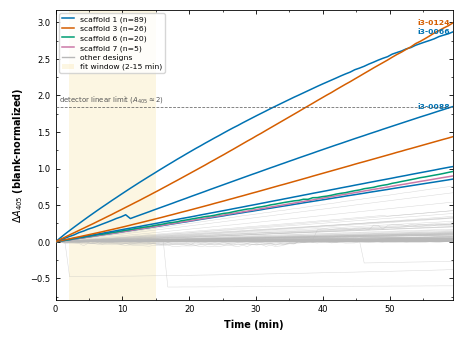

Saved figure to wetlab_data_plots/round2_screen_progress_curves_compact.png


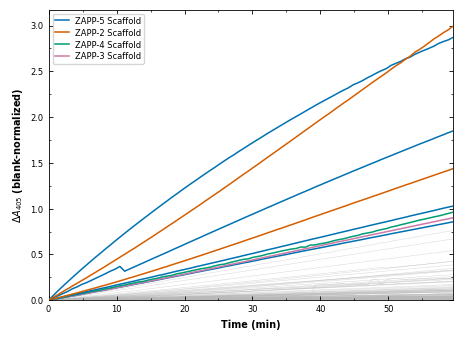

Highlighted the 8 highest-climbing designs, spanning scaffolds [np.int64(1), np.int64(3), np.int64(6), np.int64(7)]:


,reader_well,source_well,design_id,scaffold,peak_deltaA405,rate_abs_per_min
1,F7,P2C4,ZAPP_i3_AR_pte_0124,3,2.993,0.045551
0,C12,P1F6,ZAPP_i3_AR_pte_0066,1,2.870,0.061727
2,D8,P1H4,ZAPP_i3_AR_pte_0088,1,1.849,0.034874
3,E24,P2B12,ZAPP_i3_AR_pte_0120,3,1.437,0.021093
4,B18,P1D9,ZAPP_i3_AR_pte_0045,1,1.028,0.016614
5,G5,P2E3,ZAPP_i3_AR_pte_0147,6,0.961,0.014985
6,H1,P2G1,ZAPP_i3_AR_pte_0169,7,0.900,0.014090
7,C17,P1E9,ZAPP_i3_AR_pte_0057,1,0.857,0.013872


In [30]:
####################################################################
### PROGRESS CURVES COLORED BY DESIGN SCAFFOLD                   ###
####################################################################

### INPUTS ###
n_highlight = 8
screening_basename  = 'round2_screen_progress_curves'
manuscript_basename = 'round2_screen_progress_curves_compact'

### PLOT CONTROLS ###
figure_size          = (WIDTH_1COL * 1.35, WIDTH_1COL * 1.0)
background_linewidth = 0.35
background_alpha     = 0.55
highlight_linewidth  = 1.1

# manuscript display names for the hit-bearing scaffolds
MANUSCRIPT_SCAFFOLD_NAMES = {
    1: 'ZAPP-5 Scaffold',
    3: 'ZAPP-2 Scaffold',
    6: 'ZAPP-4 Scaffold',
    7: 'ZAPP-3 Scaffold',
}

#####################
### HELPER LOGIC  ###
#####################

def blank_normalized_trace(reader_well):
    """Absorbance relative to that well's first read."""
    y = abs_df[reader_well].to_numpy(dtype=float)
    return y - y[0]

# highlight the eight designs whose blank-normalized curve reaches the highest
# absorbance. No QC filtering: raw screening plates are polyclonal and unpurified.
rates_df['peak_delta_abs'] = [float(blank_normalized_trace(w).max())
                              for w in rates_df['reader_well']]
highlight_df = rates_df.nlargest(n_highlight, 'peak_delta_abs')
highlight_wells = set(highlight_df['reader_well'])
qc_fail_wells = set(rates_df.loc[~rates_df['qc_pass'], 'reader_well'])  # used by later cells

# blank-normalized absorbance at which the reader leaves its linear range
linear_ceiling_delta = ABS_LINEAR_CEILING - float(rates_df['initial_abs'].median())

#################
### PLOTTING  ###
#################

def plot_progress_curves(manuscript):
    fig, ax = plt.subplots(figsize=figure_size)

    if not manuscript:
        ax.axvspan(FIT_START_MIN, FIT_END_MIN, color=FIT_WINDOW_COLOR, alpha=0.16,
                   linewidth=0, zorder=0)

    # >> every non-highlighted well as a light gray background trace
    for reader_well in reader_well_cols:
        if reader_well in highlight_wells:
            continue
        ax.plot(time_min, blank_normalized_trace(reader_well), color=BACKGROUND_TRACE_COLOR,
                linewidth=background_linewidth, alpha=background_alpha,
                solid_capstyle='round', zorder=1)

    # >> highlighted designs, colored by scaffold (drawn lowest-peak first)
    for _, row in highlight_df.sort_values('peak_delta_abs').iterrows():
        ax.plot(time_min, blank_normalized_trace(row['reader_well']),
                color=SCAFFOLD_COLORS[row['scaffold']], linewidth=highlight_linewidth,
                solid_capstyle='round', zorder=3)

    style_science_axes(ax, x_label='Time (min)',
                       y_label=f'$\\Delta A_{{{READ_WAVELENGTH_NM}}}$ (blank-normalized)')
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.set_xlim(0, time_min[-1])

    scaffolds_shown = sorted(highlight_df['scaffold'].unique())

    if manuscript:
        # start at zero so the negative-going (bubble) traces fall off the bottom
        ax.set_ylim(bottom=0)
        handles = [Line2D([], [], color=SCAFFOLD_COLORS[s], linewidth=highlight_linewidth,
                          label=MANUSCRIPT_SCAFFOLD_NAMES.get(s, f'scaffold {s}'))
                   for s in scaffolds_shown]
        ax.legend(handles=handles, loc='upper left', fontsize=6, handlelength=1.6,
                  labelspacing=0.35, borderpad=0.3)
    else:
        # >> the fastest wells leave the reader's reliable range late in the run
        ax.axhline(linear_ceiling_delta, color='#555555', linewidth=0.5,
                   linestyle=(0, (4, 2)), zorder=4)
        ax.annotate(f'detector linear limit ($A_{{{READ_WAVELENGTH_NM}}}\\approx{ABS_LINEAR_CEILING:g}$)',
                    xy=(0.5, linear_ceiling_delta), xytext=(0, 2), textcoords='offset points',
                    ha='left', va='bottom', fontsize=5, color='#555555')
        # >> label the three highest-climbing designs directly
        for _, row in highlight_df.nlargest(3, 'peak_delta_abs').iterrows():
            trace = blank_normalized_trace(row['reader_well'])
            ax.annotate(row['design_id'].replace('ZAPP_i3_AR_pte_', 'i3-'),
                        xy=(time_min[-1], trace[-1]), xytext=(-2, 0), textcoords='offset points',
                        ha='right', va='center', fontsize=5.5,
                        color=SCAFFOLD_COLORS[row['scaffold']], fontweight='bold')
        handles = [Line2D([], [], color=SCAFFOLD_COLORS[s], linewidth=highlight_linewidth,
                          label=f'scaffold {s} (n={int((rates_df["scaffold"] == s).sum())})')
                   for s in scaffolds_shown]
        handles += [Line2D([], [], color=BACKGROUND_TRACE_COLOR, linewidth=1.0, label='other designs'),
                    Patch(facecolor=FIT_WINDOW_COLOR, alpha=0.16,
                          label=f'fit window ({FIT_START_MIN:g}-{FIT_END_MIN:g} min)')]
        ax.legend(handles=handles, loc='upper left', fontsize=5.5, handlelength=1.6,
                  labelspacing=0.35, borderpad=0.3)

    fig.tight_layout()
    return fig

save_figure(screening_basename, fig=plot_progress_curves(manuscript=False))
plt.show()
save_figure(manuscript_basename, fig=plot_progress_curves(manuscript=True))
plt.show()

print(f'Highlighted the {len(highlight_df)} highest-climbing designs, '
      f'spanning scaffolds {sorted(highlight_df["scaffold"].unique())}:')
display(highlight_df[['reader_well', 'source_well', 'design_id', 'scaffold',
                      'peak_delta_abs', 'rate_abs_per_min']]
        .rename(columns={'peak_delta_abs': 'peak_deltaA405'}))

### IV.II.D.1. Supplementary-information screening style

The additional view below reproduces the standalone screening panel from the
RFdiffusion3 supplementary-information figure. Colored curves are the designs
characterized by kinetics, with the manuscript scaffold colors and direct labels.
The gray band is the 5th–95th percentile envelope of the other designs. Every
trace is relative to its own first absorbance reading; time is in hours.
The original screening view above is retained. This display performs no new
fitting, hit calling, or filtering.


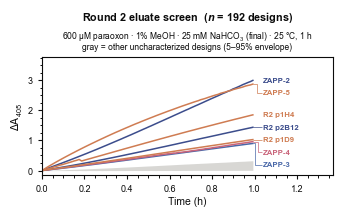

saved Manuscript_Data/Phosphotriesterase_RFdiffusion3_Science_2026/wetlab_data_plots/screen_round2_SI_style.png


In [3]:
from kinetics_pte_rfd3 import plot_screening_PTE_RFd3

screen_r2_si_plot = os.path.join(
    wetlab_data_plots_dir, 'screen_round2_SI_style.png')
plot_screening_PTE_RFd3(2, plot_path=screen_r2_si_plot, dpi=600)
print(f"saved {os.path.relpath(screen_r2_si_plot)}")


### IV.II.E. Hit Table

In [31]:
####################################################################
### EXPORT THE HIT TABLE                                          ###
####################################################################

### INPUTS ###
hits_csv = os.path.join(wetlab_data_plots_dir, 'round2_screen_hits.csv')

#################
### EXPORT    ###
#################

export_cols = [
    'activity_rank', 'design_id', 'scaffold', 'plate_number', 'well_position',
    'source_well', 'reader_well',
    'rate_abs_per_min', 'rate_corrected_abs_per_min', 'rate_um_per_min',
    'robust_z', 'fold_over_background', 'fit_r2', 'fit_residual_sd', 'fit_n_points',
    'initial_abs', 'final_abs', 'max_abs',
    'qc_pass', 'flag_optical_artifact', 'flag_above_linear_range', 'fit_segmented',
    'is_hit', 'parent',
]
export_cols = [c for c in export_cols if c in rates_df.columns]

hits_df = rates_df[rates_df['is_hit']].sort_values('activity_rank')
hits_df[export_cols].to_csv(hits_csv, index=False)

print(f'Screen summary')
print(f'  designs screened      : {len(rates_df)}')
print(f'  QC passing            : {int(rates_df["qc_pass"].sum())}')
print(f'  hits                  : {len(hits_df)} ({100 * len(hits_df) / len(rates_df):.1f}%)')
print(f'  scaffolds with a hit  : {sorted(hits_df["scaffold"].unique())}')
print(f'  best design           : {hits_df.iloc[0]["design_id"]} '
      f'(scaffold {hits_df.iloc[0]["scaffold"]}, '
      f'{hits_df.iloc[0]["fold_over_background"]:.0f}x background)')
print(f'  saved                 : {os.path.relpath(hits_csv)}')
print()
print('CAVEATS FOR THE METHODS SECTION')
print('  - n = 1 per design; the two source plates hold 192 distinct designs, not replicates.')
print('  - rates are volumetric activities of unnormalized IMAC eluate, not specific')
print('    activities, so expression level and activity are confounded.')
print('  - absolute molar rates depend on an uncalibrated pathlength and buffer pH.')
print('  - no dedicated positive/negative control wells, so no Z-factor is reportable.')
print()
display(hits_df[export_cols].head(25))

Screen summary
  designs screened      : 192
  QC passing            : 180
  hits                  : 40 (20.8%)
  scaffolds with a hit  : [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7)]
  best design           : ZAPP_i3_AR_pte_0066 (scaffold 1, 165x background)
  saved                 : wetlab_data_plots/round2_screen_hits.csv

CAVEATS FOR THE METHODS SECTION
  - n = 1 per design; the two source plates hold 192 distinct designs, not replicates.
  - rates are volumetric activities of unnormalized IMAC eluate, not specific
    activities, so expression level and activity are confounded.
  - absolute molar rates depend on an uncalibrated pathlength and buffer pH.
  - no dedicated positive/negative control wells, so no Z-factor is reportable.



,activity_rank,design_id,scaffold,plate_number,well_position,source_well,reader_well,rate_abs_per_min,rate_corrected_abs_per_min,robust_z,fold_over_background,fit_r2,fit_residual_sd,fit_n_points,initial_abs,final_abs,max_abs,qc_pass,flag_optical_artifact,flag_above_linear_range,fit_segmented,is_hit,parent
0,1,ZAPP_i3_AR_pte_0066,1,1,F6,P1F6,C12,0.061727,0.061353,279.856506,165.295302,0.999288,0.006678,19,0.392,3.262,3.262,True,False,True,False,True,ZAPP_p1D1_rotP_1_ORI_05_C9_i_14_model_2__eV2_T...
1,2,ZAPP_i3_AR_pte_0124,3,2,C4,P2C4,F7,0.045551,0.045178,206.074076,121.979866,0.999751,0.002913,19,0.248,3.241,3.241,True,False,True,False,True,ZAPP_p1D1_rotP_1_ORI_11_C9_i_12_model_3__eV2_T...
3,4,ZAPP_i3_AR_pte_0120,3,2,B12,P2B12,E24,0.021093,0.020719,94.508731,56.483222,0.999200,0.002419,19,0.208,1.645,1.645,True,False,False,False,True,ZAPP_p1D1_rotP_1_ORI_11_C9_i_12_model_3__eV2_T...
4,5,ZAPP_i3_AR_pte_0045,1,1,D9,P1D9,B18,0.016614,0.016241,74.079663,44.489933,0.999934,0.000545,19,0.214,1.242,1.242,True,False,False,False,True,ZAPP_p1D1_rotP_1_ORI_05_C9_i_14_model_2__eV2_T...
5,6,ZAPP_i3_AR_pte_0147,6,2,E3,P2E3,G5,0.014985,0.014612,66.648833,40.127517,0.999434,0.001446,19,0.275,1.236,1.236,True,False,False,False,True,ZAPP_p1D1_rotP_0_ORI_02_C6_i_9_model_1__eV2_T0...
6,7,ZAPP_i3_AR_pte_0169,7,2,G1,P2G1,H1,0.014090,0.013717,62.567592,37.731544,0.999688,0.001010,19,0.186,1.086,1.086,True,False,False,False,True,ZAPP_p1D1_rotP_1_ORI_10_C3_i_38_model_2__eV2_T...
7,8,ZAPP_i3_AR_pte_0057,1,1,E9,P1E9,C17,0.013872,0.013499,61.573004,37.147651,0.999808,0.000780,19,0.196,1.053,1.053,True,False,False,False,True,ZAPP_p1D1_rotP_1_ORI_05_C9_i_14_model_2__eV2_T...
8,9,ZAPP_i3_AR_pte_0023,1,1,B11,P1B11,A22,0.012313,0.011940,54.462271,32.973154,0.998813,0.001721,19,0.220,0.982,0.982,True,False,False,False,True,ZAPP_p1D1_rotP_1_ORI_05_C9_i_14_model_2__eV2_T...
9,10,ZAPP_i3_AR_pte_0031,1,1,C7,P1C7,B13,0.010637,0.010263,46.814232,28.483222,0.999581,0.000882,19,0.192,0.862,0.862,True,False,False,False,True,ZAPP_p1D1_rotP_1_ORI_05_C9_i_14_model_2__eV2_T...
10,11,ZAPP_i3_AR_pte_0005,1,1,A5,P1A5,A9,0.008534,0.008160,37.222744,22.852349,0.999580,0.000709,19,0.187,0.729,0.729,True,False,False,False,True,ZAPP_p1D1_rotP_1_ORI_05_C9_i_14_model_2__eV2_T...


# **V. RFdiffusion3 PAPER FIGURES**

Generate the SI kinetics/background figures, Figure 4 panels E/F/G/I and the additional tagless comparison in `wetlab_data_plots/paper_figures/`. Reference checks account for the stored precision of `paraoxon_kinetics_ALL_DATA.xlsx`.

Panel E includes an original reproduction and a `__condition_matched` variant correcting the no-bicarbonate points' calibration. The numerical fits and SI panels use condition-matched calibration throughout. See [analysis notes](REPRODUCTION.md).

The final [tagless SI artwork (PDF)](wetlab_data_plots/paper_figures/pdf/PTE__v2SI__ZAPP1_tagless.pdf) includes the intact-mass spectrum; its [source tables and methods](supplemental_data/ZAPP1_tagless/) accompany the deposited figure.


In [32]:
paper_figure_dir = reproduce_paper_figures(globals())
print(f"Paper figures: {os.path.relpath(paper_figure_dir)}")


Paper reference: 234 numerical checks passed at stored precision.
building SI kinetics figures ...


Parsing [raw_wetlab_data/260804_ZAPP1strp_24uM__p1D9_44pt6uM__p1H4_39pt1uM__80uL_1prctMeOH_trip_blank__leg_buff__9pt6mMpxn_serialDIL_30m_25finalbica.xlsx] Measured at [2026-08-05 17:07:23]...


Parsing [raw_wetlab_data/260225_p1D1_30pt9uM__p1D8_39pt8uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_20m__NObicarb_added.xlsx] Measured at [2026-02-26 01:40:30]...


Parsing [raw_wetlab_data/260224_p1D7_21pt3uM__p1E10_15pt3uM__p3C11_27pt1uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_20m__25finalbicarb_after3hr.xlsx] Measured at [2026-02-24 18:44:55]...


Parsing [raw_wetlab_data/260224_p1D1_26pt2uM__p1D8_26pt1uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_20m__25finalbicarb_after3hr.xlsx] Measured at [2026-02-24 16:55:59]...


...

wrote wetlab_data_plots/paper_figures/main_fig4/PTE__v2MAIN__fig4E__bicarbonate_MM.pdf
wrote wetlab_data_plots/paper_figures/main_fig4/PTE__v2MAIN__fig4E__bicarbonate_MM.png

  + Bicarbonate
    k\mathrm{cat} = 0.015 ± 0.003 s^-1
    K\mathrm{M} = 8 ± 2 mM
    k\mathrm{cat}/K\mathrm{M} = 2.0 ± 0.6 M^-1 s^-1
    k\mathrm{cat}/k\mathrm{uncat} = (3 ± 1) x 10^{5}
  - Bicarbonate
    k\mathrm{cat} = 0.0013 ± 0.0002 s^-1
    K\mathrm{M} = 2.6 ± 0.7 mM
    k\mathrm{cat}/K\mathrm{M} = 0.5 ± 0.2 M^-1 s^-1
    k\mathrm{cat}/k\mathrm{uncat} = (2.5 ± 0.4) x 10^{4}
Parsing [raw_wetlab_data/260804_ZAPP1strp_24uM__p1D9_44pt6uM__p1H4_39pt1uM__80uL_1prctMeOH_trip_blank__leg_buff__9pt6mMpxn_serialDIL_30m_25finalbica.xlsx] Measured at [2026-08-05 17:07:23]...


Parsing [raw_wetlab_data/260225_p1D1_30pt9uM__p1D8_39pt8uM__80uL_1prctMeOH_trip_blank__legacy_buff__9pt6mMpxn_serialDIL_20m__NObicarb_added.xlsx] Measured at [2026-02-26 01:40:30]...
wrote wetlab_data_plots/paper_figures/main_fig4/PTE__v2MAIN__fig4E__bicarbonate_MM__condition_matched.pdf


wrote wetlab_data_plots/paper_figures/main_fig4/PTE__v2MAIN__fig4E__bicarbonate_MM__condition_matched.png

  + Bicarbonate
    k\mathrm{cat} = 0.015 ± 0.003 s^-1
    K\mathrm{M} = 8 ± 2 mM
    k\mathrm{cat}/K\mathrm{M} = 2.0 ± 0.6 M^-1 s^-1
    k\mathrm{cat}/k\mathrm{uncat} = (3 ± 1) x 10^{5}
  - Bicarbonate
    k\mathrm{cat} = 0.0013 ± 0.0002 s^-1
    K\mathrm{M} = 2.6 ± 0.7 mM
    k\mathrm{cat}/K\mathrm{M} = 0.5 ± 0.2 M^-1 s^-1
    k\mathrm{cat}/k\mathrm{uncat} = (2.5 ± 0.4) x 10^{4}
wrote wetlab_data_plots/paper_figures/main_fig4/PTE__v2MAIN__fig4F__knockouts_kcatKM.pdf
wrote wetlab_data_plots/paper_figures/main_fig4/PTE__v2MAIN__fig4F__knockouts_kcatKM.png
  panel F values (M^-1 s^-1):
    WT       1.9690 +/- 0.5430
    H93A     0.0740 +/- 0.0452
    H89A     0.1624 +/- 0.0144   (first-order chord estimate)
    K16A     0.1760 +/- 0.2233
    H170A    0.0021 +/- 0.0009   (first-order chord estimate)
    H133A    0.0130 +/- 0.0061
    E92A     0.0470 +/- 0.0182
wrote wetlab_data_plot

wrote wetlab_data_plots/paper_figures/main_fig4/PTE__v2MAIN__fig4I__kcat_kcatKM.png
  panel I values:
    ZAPP-1    kcat 0.01531 +/- 0.00222   kcat/KM 1.969 +/- 0.543
    R1 p1D7   kcat 0.00320 +/- 0.00029   kcat/KM 2.206 +/- 0.506
    R1 p1D8   kcat 0.00293 +/- 0.00027   kcat/KM 1.947 +/- 0.453
    R1 p1E10  kcat 0.00186 +/- 0.00024   kcat/KM 0.753 +/- 0.246
    ZAPP-2    kcat 0.02299 +/- 0.00555   kcat/KM 4.014 +/- 2.081
    R2 p2B12  kcat 0.00393 +/- 0.00060   kcat/KM 1.160 +/- 0.416
    ZAPP-3    kcat 0.01005 +/- 0.00273   kcat/KM 1.689 +/- 0.980
    ZAPP-4    kcat 0.01032 +/- 0.00186   kcat/KM 3.060 +/- 1.332
    ZAPP-5    kcat 0.00789 +/- 0.00189   kcat/KM 1.151 +/- 0.565
    R2 p1D9   kcat 0.00565 +/- 0.00207   kcat/KM 0.416 +/- 0.273
    R2 p1H4   kcat 0.00250 +/- 0.00051   kcat/KM 0.340 +/- 0.140
scaffold -> family, derived from the plate wells: {1: 'ZAPP-5', 3: 'ZAPP-2', 6: 'ZAPP-4', 7: 'ZAPP-3'}
wrote wetlab_data_plots/paper_figures/main_fig4/PTE__v2MAIN__fig4G__screen_progr

wrote wetlab_data_plots/paper_figures/main_fig4/PTE__v2MAIN__fig4G__screen_progress.png
axes box 37.5 x 33.0 mm (target 37.5 x 33.0)
type: axis titles and ticks 7.5 pt, legend and callouts 6.0 pt
canvas 61.50 x 46.30 mm; axes inset 11.00 mm from the left, 4.30 from the top
place at X = 147.73 mm, Y = 45.70 mm (Inkscape, 100%)

highlighted traces, most active first:
   ZAPP-2    p2C4   ZAPP-2  ends at 2.99
   ZAPP-5    p1F6   ZAPP-5  ends at 2.87
   R2 p1H4   p1H4   ZAPP-5  ends at 1.85
   R2 p2B12  p2B12  ZAPP-2  ends at 1.44
   R2 p1D9   p1D9   ZAPP-5  ends at 1.03
   ZAPP-4    p2E3   ZAPP-4  ends at 0.96
   ZAPP-3    p2G1   ZAPP-3  ends at 0.90
Paper figures: wetlab_data_plots/paper_figures
